Importing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
import xgboost as xgb

from xgboost import XGBClassifier

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    LogisticRegression
)

from sklearn.neighbors import (
    KNeighborsRegressor,
    KNeighborsClassifier
)

from sklearn.svm import (
    SVR,
    SVC
)

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    learning_curve
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

In [3]:
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.model_selection import KFold, cross_val_score

import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostRegressor, CatBoostClassifier

STEP 1: loading data

In [4]:

df = pd.read_csv(r"D:\algal4\RF_Inputs_Normalized.csv")
print(f"RF_Inputs_Normalized.csv loaded successfully")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Lakes surveyed:      {df['LAKENAME'].nunique()} unique lakes")
print(f"Years covered:       {sorted(df['Year'].unique())}")
print(f"Months covered:      {sorted(df['Month'].unique())} (May–Oct bloom season)")

RF_Inputs_Normalized.csv loaded successfully
Rows: 2226
Columns: 67
Lakes surveyed:      1649 unique lakes
Years covered:       [np.int64(2007), np.int64(2012)]
Months covered:      [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] (May–Oct bloom season)


In [5]:

# 1. What are we working with?
print("=" * 60)
print("BASIC DATA INSPECTION")
print("=" * 60)

# 2. Shape - how big is this?
print(f"\n1. DATASET SIZE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

# 3. What are all the column names?
print(f"\n2. ALL COLUMN NAMES:")
print(df.columns.tolist())

# 4. What types of data in each column?
print(f"\n3. DATA TYPES (what is each column):")
print(df.dtypes)

# 5. First few rows - see actual data
print(f"\n4. FIRST 5 ROWS (see what values look like):")
print(df.head())

# 6. Statistical summary of numeric columns
print(f"\n5. STATISTICS OF NUMERIC COLUMNS:")
print(df.describe())

# 7. Check for problems in each column
print(f"\n6. PROBLEM CHECK - Missing values and unique values:")
for col in df.columns:
    missing = df[col].isnull().sum()
    unique = df[col].nunique()
    dtype = df[col].dtype
    
    # Only print columns that might have issues
    if missing > 0 or dtype == 'object':
        print(f"   {col}:")
        print(f"      Type: {dtype}")
        print(f"      Missing: {missing} ({missing/len(df)*100:.1f}%)")
        print(f"      Unique values: {unique}")
        
        # If it's object/string, show some examples
        if dtype == 'object' and unique < 20:
            print(f"      Example values: {df[col].unique()[:5]}")

BASIC DATA INSPECTION

1. DATASET SIZE:
   Rows: 2226
   Columns: 67

2. ALL COLUMN NAMES:
['LAKENAME', 'Survey Number', 'SITE_ID', 'Year', 'Month', 'Day', 'LAT_DD', 'LON_DD', 'WSAREA_km2', 'lake_AREA_HA', 'NTL', 'PTL', 'SNOW', 'SNOW_YrMean', 'FIRE', 'FIRE_YrMean', 'LST', 'LST_YrMean', 'NPP', 'NPP_YrMean', 'Precip', 'Precip_YrMean', 'Tmean', 'Tmean_YrMean', 'Atmo_Pdep_2002', 'Atmo_Pdep_2007', 'Tot_Ndep_2000', 'Tot_Ndep_2007', 'Tot_Sdep_2000', 'Tot_Sdep_2007', 'N_CBNF_2007', 'N_Crop_N_Rem_2007', 'N_Fert_Farm_2007', 'N_Fert_Urban_2007', 'Human_N_Demand_2007', 'N_Human_Waste_2007', 'N_Livestock_Food_Demand_2007', 'N_Livestock.Waste_2007', 'N_Livestock_N_Content_2007', 'N_Rock_2007', 'nani', 'P_Crop_removal_2007', 'P_f_fertilizer_2007', 'P_livestock_demand_2007', 'P_livestock_Waste_2007', 'P_livestock_production_2007', 'P_nf_fertilizer_2007', 'P_human_food_demand_kg_2007', 'P_human_nonfood_demand_kg_2007', 'P_human_waste_kg_2007', 'P_Accumulated_ag_inputs_2007', 'NAPI', 'Total Input', 'Leg

In [6]:
# ================================================================
# FIX: Clean the #DIV/0! errors in logchl_A and other columns
# ================================================================
print("\n" + "─" * 65)
print("DATA CLEANING: Fixing #DIV/0! errors")
print("─" * 65)

# Check for #DIV/0! in target column before fixing
initial_bad_rows = (df['logchl_A'] == '#DIV/0!').sum()
print(f"Rows with '#DIV/0!' in logchl_A: {initial_bad_rows}")

# Convert the target column from string/object to numeric
# This will turn '#DIV/0!' into NaN (missing value)
df['logchl_A'] = pd.to_numeric(df['logchl_A'], errors='coerce')

# Check how many became NaN (missing)
nan_count = df['logchl_A'].isna().sum()
print(f"Rows with invalid/NaN logchl_A after conversion: {nan_count}")

# OPTION 1: Drop rows with missing target (recommended for this dataset)
if nan_count > 0:
    print(f"Dropping {nan_count} rows with invalid logchl_A values...")
    df = df.dropna(subset=['logchl_A'])
    print(f"Remaining rows: {len(df)}")

# OPTION 2: If you want to fill instead of drop (use carefully):
# median_value = df['logchl_A'].median()
# df['logchl_A'] = df['logchl_A'].fillna(median_value)

# Also clean any OTHER columns that might have '#DIV/0!'
print("\nChecking other columns for '#DIV/0!' values...")
bad_columns = []
for col in df.columns:
    if df[col].dtype == 'object':  # Only check string columns
        bad_count = (df[col] == '#DIV/0!').sum()
        if bad_count > 0:
            bad_columns.append(col)
            print(f"  {col}: {bad_count} '#DIV/0!' values")
            # Convert to numeric (turns '#DIV/0!' into NaN)
            df[col] = pd.to_numeric(df[col], errors='coerce')

# If you dropped rows, reset the index
df = df.reset_index(drop=True)

print(f"\n✅ Data cleaning complete. Final dataset: {len(df)} rows")
print(f"✅ Target variable now numeric - min: {df['logchl_A'].min():.3f}, max: {df['logchl_A'].max():.3f}")


─────────────────────────────────────────────────────────────────
DATA CLEANING: Fixing #DIV/0! errors
─────────────────────────────────────────────────────────────────
Rows with '#DIV/0!' in logchl_A: 131
Rows with invalid/NaN logchl_A after conversion: 131
Dropping 131 rows with invalid logchl_A values...
Remaining rows: 2095

Checking other columns for '#DIV/0!' values...
  Depth: 20 '#DIV/0!' values

✅ Data cleaning complete. Final dataset: 2095 rows
✅ Target variable now numeric - min: 0.000, max: 2.941


In [7]:
# ================================================================
# CONVERT ALL OBJECT COLUMNS TO NUMBERS (like logchl_A fix)
# ================================================================

print("\n" + "="*60)
print("CONVERTING TEXT COLUMNS TO NUMBERS")
print("="*60)

# Step 1: See which columns are objects (text)
object_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nFound {len(object_cols)} text/object columns:")
print(object_cols[:20])  # Show first 20

# Step 2: Convert ALL of them to numbers (same as you did for logchl_A)
for col in object_cols:
    # Try to convert to number, '#DIV/0!' becomes NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"   Converted: {col}")

# Step 3: Check what's left as text
still_object = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nColumns still text (these are real text like lake names): {still_object}")

# Step 4: Drop the real text columns (lake names, IDs) - they're useless for math
for col in still_object:
    df = df.drop(columns=[col])
    print(f"   Dropped: {col}")

print(f"\n✅ FINAL: {len(df.columns)} columns, all numeric!")
print(f"✅ Now NTL is float: {df['NTL'].dtype}")
print(f"✅ Now PTL is float: {df['PTL'].dtype}")


CONVERTING TEXT COLUMNS TO NUMBERS

Found 4 text/object columns:
['LAKENAME', 'SITE_ID', 'NTL', 'PTL']
   Converted: LAKENAME
   Converted: SITE_ID
   Converted: NTL
   Converted: PTL

Columns still text (these are real text like lake names): []

✅ FINAL: 67 columns, all numeric!
✅ Now NTL is float: float64
✅ Now PTL is float: float64


In [8]:
for col in df.columns:
    if df[col].dtype in ['float64', 'float32']:
        df[col].fillna(df[col].median(), inplace=True)

print(f"✅ Data cleaned: {len(df)} rows, {len(df.columns)} columns")

✅ Data cleaned: 2095 rows, 67 columns


In [9]:
# ================================================================
# DELETE COLUMNS WITH >40% MISSING VALUES
# ================================================================

print("\n" + "─" * 65)
print("STEP: Removing columns with >40% missing values")
print("─" * 65)

# Calculate missing percentage for each column
missing_pct = df.isnull().sum() / len(df) * 100

# Find columns to drop
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()

print(f"Found {len(cols_to_drop)} columns with >40% missing values:")

if len(cols_to_drop) > 0:
    for col in cols_to_drop[:10]:  # Show first 10
        print(f"   {col}: {missing_pct[col]:.1f}% missing")
    
    if len(cols_to_drop) > 10:
        print(f"   ... and {len(cols_to_drop) - 10} more")
    
    # Drop the bad columns
    df = df.drop(columns=cols_to_drop)
    print(f"\n✅ Removed {len(cols_to_drop)} columns")
else:
    print("✅ No columns with >40% missing values found")

print(f"Remaining columns: {len(df.columns)}")


─────────────────────────────────────────────────────────────────
STEP: Removing columns with >40% missing values
─────────────────────────────────────────────────────────────────
Found 2 columns with >40% missing values:
   LAKENAME: 100.0% missing
   SITE_ID: 100.0% missing

✅ Removed 2 columns
Remaining columns: 65


Exploring the data

In [10]:
print("Target variable:logchl_A")
print(df['logchl_A'].describe().round(2))
print(f"\nThis means chlorophyll-a ranges from:")
print(f"  Min:  10^{df['logchl_A'].min():.2f} = {10**df['logchl_A'].min():.1f} µg/L  (very clear lake)")
print(f"  Mean: 10^{df['logchl_A'].mean():.2f} = {10**df['logchl_A'].mean():.1f} µg/L  (typical US lake)")
print(f"  Max:  10^{df['logchl_A'].max():.2f} = {10**df['logchl_A'].max():.1f} µg/L  (heavy bloom)")

print("\n--- HAB threshold: WHO considers >10 µg/L = bloom risk ---")
chla_actual = 10 ** df['logchl_A']
above_10  = (chla_actual > 10).sum()
above_50  = (chla_actual > 50).sum()
above_100 = (chla_actual > 100).sum()
print(f"  Lakes > 10 µg/L (bloom risk):    {above_10}  ({100*above_10/len(df):.1f}%)")
print(f"  Lakes > 50 µg/L (serious bloom): {above_50}  ({100*above_50/len(df):.1f}%)")
print(f"  Lakes > 100 µg/L (severe bloom): {above_100}  ({100*above_100/len(df):.1f}%)")

print(f"\n--- Years in dataset ---")
print(df['Year'].value_counts().sort_index().to_string())
print(f"\n--- Months sampled ---")
print(df['Month'].value_counts().sort_index().to_string())
print("(Note: NLA samples only in May–Oct, which is bloom season)")



Target variable:logchl_A
count    2095.00
mean        1.05
std         0.56
min         0.00
25%         0.61
50%         0.96
75%         1.44
max         2.94
Name: logchl_A, dtype: float64

This means chlorophyll-a ranges from:
  Min:  10^0.00 = 1.0 µg/L  (very clear lake)
  Mean: 10^1.05 = 11.3 µg/L  (typical US lake)
  Max:  10^2.94 = 872.2 µg/L  (heavy bloom)

--- HAB threshold: WHO considers >10 µg/L = bloom risk ---
  Lakes > 10 µg/L (bloom risk):    1007  (48.1%)
  Lakes > 50 µg/L (serious bloom): 309  (14.7%)
  Lakes > 100 µg/L (severe bloom): 129  (6.2%)

--- Years in dataset ---
Year
2007    1099
2012     996

--- Months sampled ---
Month
5      51
6     391
7     698
8     657
9     289
10      9
(Note: NLA samples only in May–Oct, which is bloom season)


In [11]:
print("\n" + "─" * 65)
print("STEP 3: Feature Engineering")
print("─" * 65)
df = df.copy()



─────────────────────────────────────────────────────────────────
STEP 3: Feature Engineering
─────────────────────────────────────────────────────────────────


In [12]:
# ── A. N:P RATIO ─────────────────────────────────────────────────
# The nitrogen-to-phosphorus molar ratio determines WHICH algae
# dominate. When N:P < 16 (Redfield Ratio), nitrogen is limiting
# and cyanobacteria (HAB species) have a competitive advantage
# because they can fix atmospheric N₂. This is Liebig's Law of
# the Minimum applied to algal ecology.
df['NP_ratio'] = df['NTL'] / (df['PTL'] + 1e-6)
df['NP_ratio'] = df['NP_ratio'].clip(0, 200)


In [13]:
# ── B. LOG TRANSFORMS OF SKEWED VARIABLES ────────────────────────
# NTL, PTL, lake_AREA_HA, WSAREA_km2 are right-skewed
# (most lakes are small, a few are enormous).
# Log transform compresses extreme values.
# np.log1p = log(1 + x) handles zeros safely.
df['log_NTL']        = np.log1p(df['NTL'])
df['log_PTL']        = np.log1p(df['PTL'])
df['log_lake_area']  = np.log1p(df['lake_AREA_HA'])
df['log_ws_area']    = np.log1p(df['WSAREA_km2'])
df['log_Depth']      = np.log1p(df['Depth'])


In [14]:
# ── C. TOTAL ANTHROPOGENIC NUTRIENT PRESSURE ─────────────────────
# Combines all the individual nutrient source columns into a single
# "total human nutrient pressure" score. Lakes with high values
# receive nutrients from multiple human sources simultaneously.
n_pressure_cols = [c for c in df.columns if c.startswith('N_') and '2007' in c]
p_pressure_cols = [c for c in df.columns if c.startswith('P_') and '2007' in c]
df['total_N_pressure'] = df[n_pressure_cols].sum(axis=1)
df['total_P_pressure'] = df[p_pressure_cols].sum(axis=1)


In [15]:
# ── D. SEASONAL BLOOM RISK FLAG ───────────────────────────────────
# July and August are peak bloom months in the USA because:
#   - Water temperatures are highest (accelerates algal growth)
#   - Solar radiation is maximum (fuels photosynthesis)
#   - Lakes are thermally stratified (traps nutrients near surface)
df['peak_bloom_month'] = df['Month'].isin([7, 8]).astype(int)


In [16]:

# ── E. LAKE SIZE CATEGORY ─────────────────────────────────────────
# Small, shallow lakes warm faster and are more vulnerable to blooms.
# Large deep lakes mix better and resist eutrophication longer.
df['small_lake'] = (df['lake_AREA_HA'] < 20).astype(int)  # < 20 hectares


In [17]:
# ── F. WATERSHED-TO-LAKE AREA RATIO ──────────────────────────────
# A large watershed draining into a small lake = concentrated
# nutrient delivery. This ratio captures that pressure.
df['ws_lake_ratio'] = df['WSAREA_km2'] / (df['lake_AREA_HA'] / 100 + 0.001)
df['ws_lake_ratio'] = np.log1p(df['ws_lake_ratio'].clip(0, 10000))


In [18]:
# ── G. CLIMATE ANOMALY: MONTHLY vs ANNUAL DEVIATION ──────────────
# If the sampling month is hotter than the annual average, that
# increases bloom risk. We capture this as a delta (deviation).
df['temp_anomaly']   = df['Tmean']   - df['Tmean_YrMean']
df['precip_anomaly'] = df['Precip']  - df['Precip_YrMean']
df['LST_anomaly']    = df['LST']     - df['LST_YrMean']
df['NPP_anomaly']    = df['NPP']     - df['NPP_YrMean']


In [19]:
# ── H. BASEFLOW INDEX INTERACTION WITH NUTRIENTS ──────────────────
# BFI (baseflow index) = fraction of streamflow that is groundwater.
# High BFI + high N/P = nutrients leaching slowly from soil
# into lake year-round (persistent nutrient supply).
df['bfi_x_napi']  = df['BFIWs'] * df['NAPI']
df['bfi_x_nani']  = df['BFIWs'] * df['nani']


In [20]:
# ── I. PHOSPHORUS LEGACY INTERACTION ─────────────────────────────
# Legacy P = accumulated historical phosphorus in soils from
# decades of farming. It releases slowly and drives blooms even
# after fertiliser use stops. Interaction with current P input:
df['legacy_x_p_input'] = df['Legacy'] * df['Total Input']

print(f"✅ Added {16} engineered features")
print(f"   NP_ratio, log transforms, nutrient pressure totals,")
print(f"   seasonal flags, watershed ratio, climate anomalies,")
print(f"   baseflow interactions, legacy phosphorus interaction")


✅ Added 16 engineered features
   NP_ratio, log transforms, nutrient pressure totals,
   seasonal flags, watershed ratio, climate anomalies,
   baseflow interactions, legacy phosphorus interaction


In [21]:
# ================================================================
# STEP 4 — DEFINE FEATURE GROUPS AND SELECT ALL FEATURES
# ================================================================
# We organise features into 6 groups — this helps us understand
# which TYPE of variable is most important.
# ================================================================

print("\n" + "─" * 65)
print("STEP 4: Feature Selection")
print("─" * 65)



─────────────────────────────────────────────────────────────────
STEP 4: Feature Selection
─────────────────────────────────────────────────────────────────


In [22]:

# ── GROUP 1: Core Water Chemistry (measured in the lake itself) ──
# These are the most direct indicators of bloom conditions.
# NTL = Total Nitrogen, PTL = Total Phosphorus
CHEMISTRY = ['NTL', 'PTL', 'log_NTL', 'log_PTL', 'NP_ratio']

# ── GROUP 2: Climate Variables (from PRISM climate dataset) ──────
# Temperature and precipitation drive seasonal bloom patterns.
# Monthly values + annual means + anomalies we computed above.
CLIMATE = [
    'Tmean', 'Tmean_YrMean', 'temp_anomaly',
    'Precip', 'Precip_YrMean', 'precip_anomaly',
    'LST', 'LST_YrMean', 'LST_anomaly',       # Land Surface Temperature
    'NPP', 'NPP_YrMean', 'NPP_anomaly',        # Net Primary Productivity
    'SNOW', 'SNOW_YrMean',                      # Snow cover (mountain lakes)
    'FIRE', 'FIRE_YrMean',                      # Fire disturbance
    'peak_bloom_month',                         # Jul/Aug flag
]

# ── GROUP 3: Atmospheric Deposition (from NADP) ──────────────────
# Nitrogen and phosphorus fall from the air as rain/dust.
# Industrial emissions and ammonia from farms deposit nutrients.
ATMOSPHERIC = [
    'Atmo_Pdep_2002', 'Atmo_Pdep_2007',
    'Tot_Ndep_2000', 'Tot_Ndep_2007',
    'Tot_Sdep_2000', 'Tot_Sdep_2007',          # Sulfur deposition
]

# ── GROUP 4: Anthropogenic Nutrient Inputs (from NNI) ────────────
# This is the most detailed feature group. NNI tracks where
# every kilogram of N and P in the landscape comes from:
# farms, cities, livestock, humans, air, geology.
# NANI = Net Anthropogenic Nitrogen Inputs (summary score)
# NAPI = Net Anthropogenic Phosphorus Inputs (summary score)
ANTHROPOGENIC_N = [
    'N_CBNF_2007',              # Biological N fixation by crops
    'N_Crop_N_Rem_2007',        # N removed by crop harvest
    'N_Fert_Farm_2007',         # Farm fertiliser N
    'N_Fert_Urban_2007',        # Urban lawn fertiliser N
    'Human_N_Demand_2007',      # N consumed by humans
    'N_Human_Waste_2007',       # N from sewage/human waste
    'N_Livestock_Food_Demand_2007',   # N in livestock feed
    'N_Livestock.Waste_2007',         # N in livestock manure
    'N_Livestock_N_Content_2007',     # N in livestock products
    'N_Rock_2007',              # Natural N from rock weathering
    'nani',                     # Summary: total anthropogenic N
    'total_N_pressure',         # Our engineered sum
]

ANTHROPOGENIC_P = [
    'P_Crop_removal_2007',      # P removed by crops
    'P_f_fertilizer_2007',      # Farm phosphorus fertiliser
    'P_livestock_demand_2007',  # P in livestock feed
    'P_livestock_Waste_2007',   # P in livestock manure
    'P_livestock_production_2007',  # P in livestock products
    'P_nf_fertilizer_2007',     # Urban phosphorus fertiliser
    'P_human_food_demand_kg_2007',  # P humans consume
    'P_human_nonfood_demand_kg_2007', # P in detergents/other
    'P_human_waste_kg_2007',    # P from sewage
    'P_Accumulated_ag_inputs_2007',  # Cumulative P built up in soil
    'NAPI',                     # Summary: total anthropogenic P
    'Total Input',              # Total P input
    'Legacy',                   # Historical/legacy P in soils
    'total_P_pressure',         # Our engineered sum
    'legacy_x_p_input',         # Our interaction term
]

# ── GROUP 5: Landscape / Watershed (from LakeCat) ─────────────────
# Characteristics of the land area draining into the lake.
# Soil type affects how much nutrient runs off vs stays in soil.
# Dam density affects water residence time.
# Wetlands filter nutrients before they reach the lake.
LANDSCAPE = [
    'DamDensWs',        # Dams slow water flow → more nutrient settling
    'PctWdWet2011Ws',   # Woody wetlands (trees/shrubs in wet areas)
    'PctHbWet2011Ws',   # Herbaceous wetlands (grasses/sedges)
    'wetlands',         # Total wetland cover (N/P filter)
    'RunoffWs',         # How fast water runs off the land
    'ClayWs',           # Clay soils → more runoff, less infiltration
    'SandWs',           # Sandy soils → more infiltration, less runoff
    'OmWs',             # Organic matter → holds nutrients
    'BFIWs',            # Baseflow index: groundwater vs surface flow
    'AgKffactWs',       # Soil erodibility on agricultural land
    'P2O5Ws',           # Soil phosphorus content
    'bfi_x_napi',       # Our engineered BFI × P interaction
    'bfi_x_nani',       # Our engineered BFI × N interaction
]

# ── GROUP 6: Lake Physical Characteristics ────────────────────────
# The lake's own geometry matters:
# Shallow lakes warm faster, mix less, bloom more easily.
# Large watersheds deliver more nutrients per unit lake area.
PHYSICAL = [
    'Month', 'Year',
    'LAT_DD', 'LON_DD',               # Location
    'lake_AREA_HA', 'log_lake_area',  # Lake size
    'WSAREA_km2', 'log_ws_area',      # Watershed size
    'Depth', 'log_Depth',             # Lake depth (shallow = more vulnerable)
    'small_lake',                     # Our binary flag
    'ws_lake_ratio',                  # Our watershed:lake area ratio
]

# ── COMBINE ALL FEATURES ──────────────────────────────────────────
ALL_FEATURES = (CHEMISTRY + CLIMATE + ATMOSPHERIC +
                ANTHROPOGENIC_N + ANTHROPOGENIC_P +
                LANDSCAPE + PHYSICAL)

# Keep only features that actually exist in the DataFrame
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

TARGET = 'logchl_A'

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

# Fill missing values with column median
# (some NNI columns have NaN for wilderness/protected areas
#  with no agricultural activity — correctly filled with 0-like median)
X = X.fillna(X.median())

print(f"✅ Total features: {len(ALL_FEATURES)}")
print(f"   Chemistry:      {len([f for f in ALL_FEATURES if f in CHEMISTRY])}")
print(f"   Climate:        {len([f for f in ALL_FEATURES if f in CLIMATE])}")
print(f"   Atmospheric:    {len([f for f in ALL_FEATURES if f in ATMOSPHERIC])}")
print(f"   Anthro-N:       {len([f for f in ALL_FEATURES if f in ANTHROPOGENIC_N])}")
print(f"   Anthro-P:       {len([f for f in ALL_FEATURES if f in ANTHROPOGENIC_P])}")
print(f"   Landscape:      {len([f for f in ALL_FEATURES if f in LANDSCAPE])}")
print(f"   Physical:       {len([f for f in ALL_FEATURES if f in PHYSICAL])}")
print(f"\n✅ Dataset: {X.shape[0]} samples × {X.shape[1]} features")
print(f"✅ NaN remaining: {X.isnull().sum().sum()}")


✅ Total features: 80
   Chemistry:      5
   Climate:        17
   Atmospheric:    6
   Anthro-N:       12
   Anthro-P:       15
   Landscape:      13
   Physical:       12

✅ Dataset: 2095 samples × 80 features
✅ NaN remaining: 0



─────────────────────────────────────────────────────────────────
STEP 5: Exploratory Data Analysis — Creating Charts
─────────────────────────────────────────────────────────────────


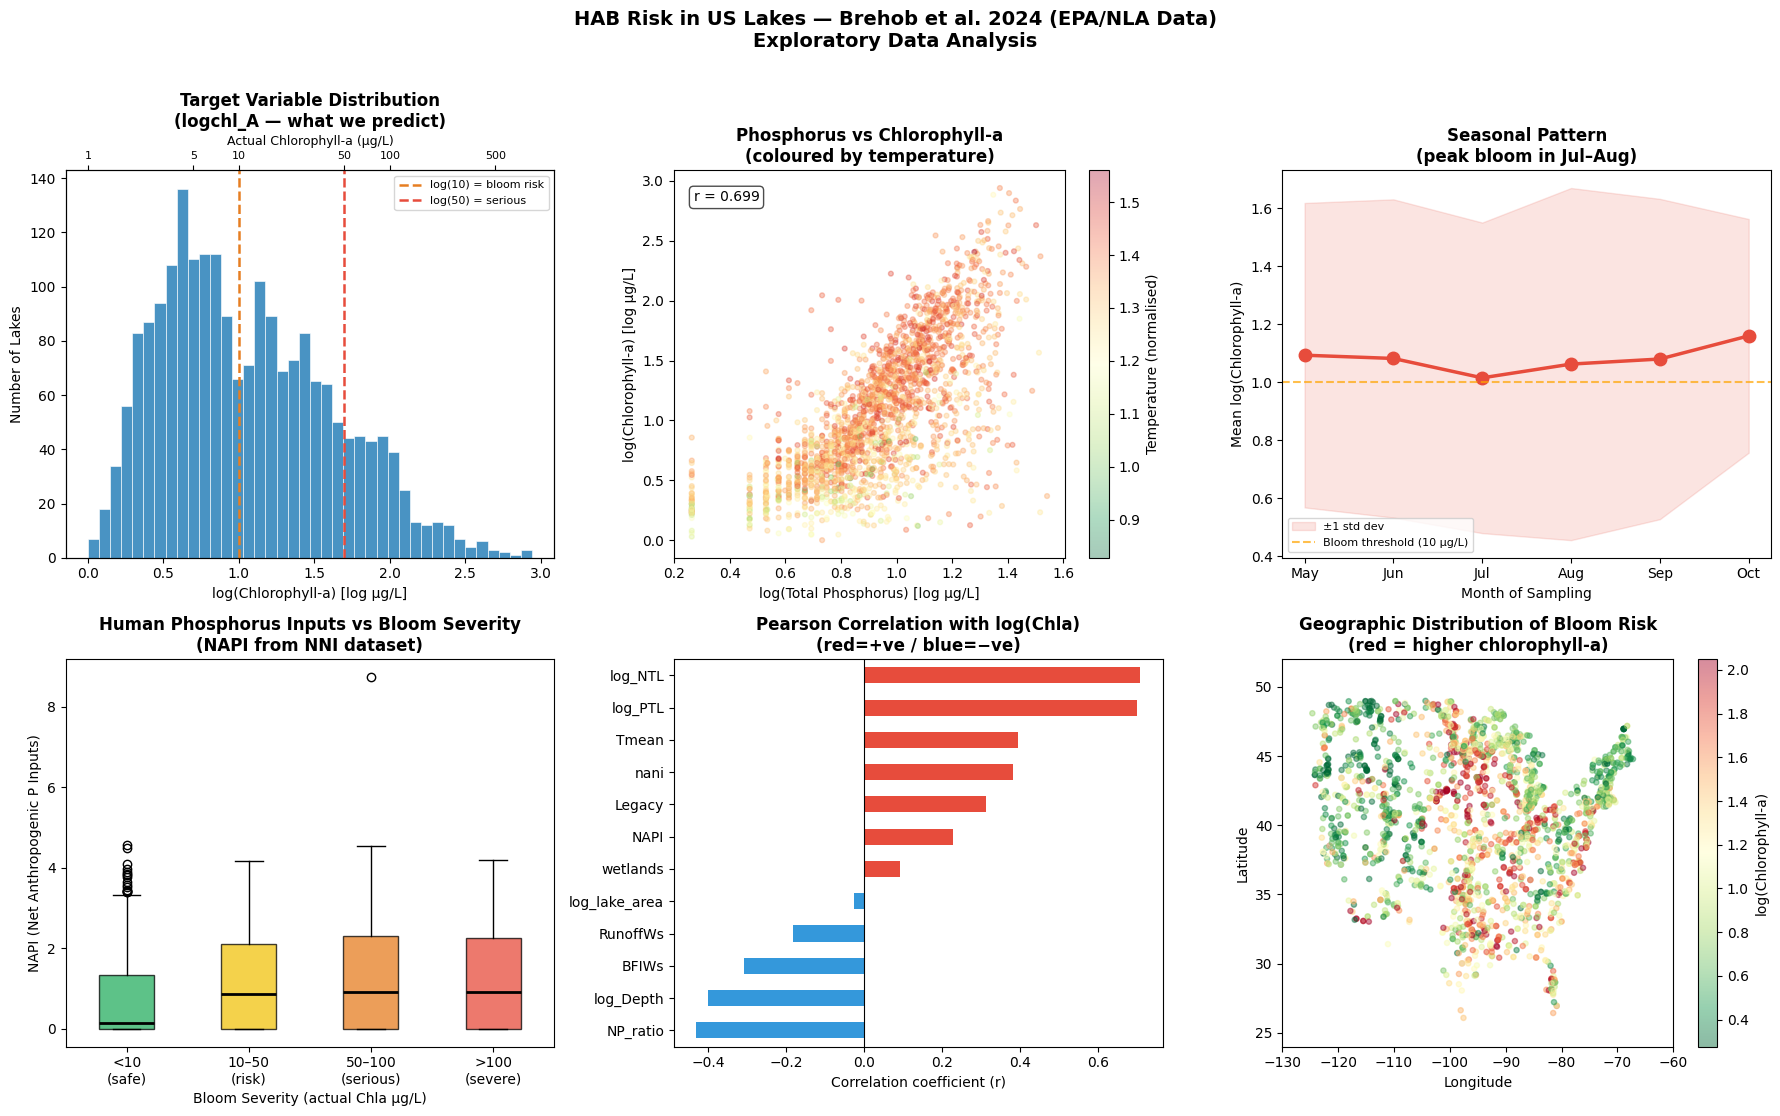

✅ EDA charts saved: brehob_eda.png


In [23]:
# ================================================================
# STEP 5 — EXPLORATORY DATA ANALYSIS (6 CHARTS)
# ================================================================

print("\n" + "─" * 65)
print("STEP 5: Exploratory Data Analysis — Creating Charts")
print("─" * 65)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'HAB Risk in US Lakes — Brehob et al. 2024 (EPA/NLA Data)\n'
    'Exploratory Data Analysis',
    fontsize=14, fontweight='bold', y=1.01
)

# ── Chart 1: Distribution of logchl_A (target variable) ──────────
ax = axes[0, 0]
ax.hist(y, bins=40, color='#2980b9', edgecolor='white',
        linewidth=0.5, alpha=0.85)
# Mark WHO thresholds on log scale
for threshold, label, color in [
    (1.0, 'log(10) = bloom risk', '#e67e22'),
    (np.log10(50), 'log(50) = serious', '#e74c3c'),
]:
    ax.axvline(threshold, color=color, linestyle='--', linewidth=1.8, label=label)
ax.set_xlabel('log(Chlorophyll-a) [log µg/L]', fontsize=10)
ax.set_ylabel('Number of Lakes', fontsize=10)
ax.set_title('Target Variable Distribution\n(logchl_A — what we predict)', fontweight='bold')
ax.legend(fontsize=8)
# Add secondary x-axis showing real µg/L values
ax2 = ax.twiny()
tick_positions = [np.log10(v) for v in [1, 5, 10, 50, 100, 500]]
tick_labels = ['1', '5', '10', '50', '100', '500']
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([t for t in tick_positions if ax.get_xlim()[0] <= t <= ax.get_xlim()[1]])
ax2.set_xticklabels([l for t, l in zip(tick_positions, tick_labels)
                     if ax.get_xlim()[0] <= t <= ax.get_xlim()[1]], fontsize=8)
ax2.set_xlabel('Actual Chlorophyll-a (µg/L)', fontsize=9)

# ── Chart 2: Total Phosphorus vs Chlorophyll-a ───────────────────
ax = axes[0, 1]
sc = ax.scatter(df['log_PTL'], y, c=df['Tmean'],
                cmap='RdYlGn_r', alpha=0.35, s=12)
plt.colorbar(sc, ax=ax, label='Temperature (normalised)')
ax.set_xlabel('log(Total Phosphorus) [log µg/L]', fontsize=10)
ax.set_ylabel('log(Chlorophyll-a) [log µg/L]', fontsize=10)
ax.set_title('Phosphorus vs Chlorophyll-a\n(coloured by temperature)',
             fontweight='bold')
# Add correlation
r = np.corrcoef(df['log_PTL'].fillna(0), y)[0, 1]
ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# ── Chart 3: Seasonal pattern ─────────────────────────────────────
ax = axes[0, 2]
monthly_mean = df.groupby('Month')[TARGET].mean()
monthly_std  = df.groupby('Month')[TARGET].std()
months_x     = monthly_mean.index
ax.plot(months_x, monthly_mean.values, 'o-', color='#e74c3c',
        linewidth=2.5, markersize=9)
ax.fill_between(months_x,
                monthly_mean - monthly_std,
                monthly_mean + monthly_std,
                alpha=0.15, color='#e74c3c', label='±1 std dev')
ax.axhline(y=1.0, color='orange', linestyle='--', alpha=0.7, label='Bloom threshold (10 µg/L)')
month_names = {5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct'}
ax.set_xticks(list(month_names.keys()))
ax.set_xticklabels(list(month_names.values()))
ax.set_xlabel('Month of Sampling', fontsize=10)
ax.set_ylabel('Mean log(Chlorophyll-a)', fontsize=10)
ax.set_title('Seasonal Pattern\n(peak bloom in Jul–Aug)', fontweight='bold')
ax.legend(fontsize=8)

# ── Chart 4: NAPI (P inputs) by bloom category ───────────────────
ax = axes[1, 0]
df['bloom_category'] = pd.cut(10**y,
    bins=[0, 10, 50, 100, 9999],
    labels=['<10\n(safe)', '10–50\n(risk)', '50–100\n(serious)', '>100\n(severe)']
)
napi_by_bloom = [df[df['bloom_category'] == cat]['NAPI'].dropna()
                 for cat in ['<10\n(safe)', '10–50\n(risk)', '50–100\n(serious)', '>100\n(severe)']]
bp = ax.boxplot(napi_by_bloom,
                labels=['<10\n(safe)', '10–50\n(risk)', '50–100\n(serious)', '>100\n(severe)'],
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
colors_bp = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xlabel('Bloom Severity (actual Chla µg/L)', fontsize=10)
ax.set_ylabel('NAPI (Net Anthropogenic P Inputs)', fontsize=10)
ax.set_title('Human Phosphorus Inputs vs Bloom Severity\n(NAPI from NNI dataset)',
             fontweight='bold')

# ── Chart 5: Correlation of top features with target ─────────────
ax = axes[1, 1]
key_features = ['log_PTL', 'log_NTL', 'NP_ratio', 'NAPI', 'nani',
                'Legacy', 'Tmean', 'log_Depth', 'wetlands',
                'log_lake_area', 'BFIWs', 'RunoffWs']
key_features = [f for f in key_features if f in df.columns]
corr_vals = df[key_features + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_vals]
corr_vals.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with log(Chla)\n(red=+ve / blue=−ve)',
             fontweight='bold')
ax.set_xlabel('Correlation coefficient (r)')

# ── Chart 6: Geographic scatter map ──────────────────────────────
ax = axes[1, 2]
sc = ax.scatter(
    df['LON_DD'], df['LAT_DD'],
    c=y, cmap='RdYlGn_r',
    alpha=0.45, s=14,
    vmin=y.quantile(0.05), vmax=y.quantile(0.95)
)
plt.colorbar(sc, ax=ax, label='log(Chlorophyll-a)')
ax.set_xlim(-130, -60)
ax.set_ylim(24, 52)
ax.set_title('Geographic Distribution of Bloom Risk\n(red = higher chlorophyll-a)',
             fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('brehob_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA charts saved: brehob_eda.png")


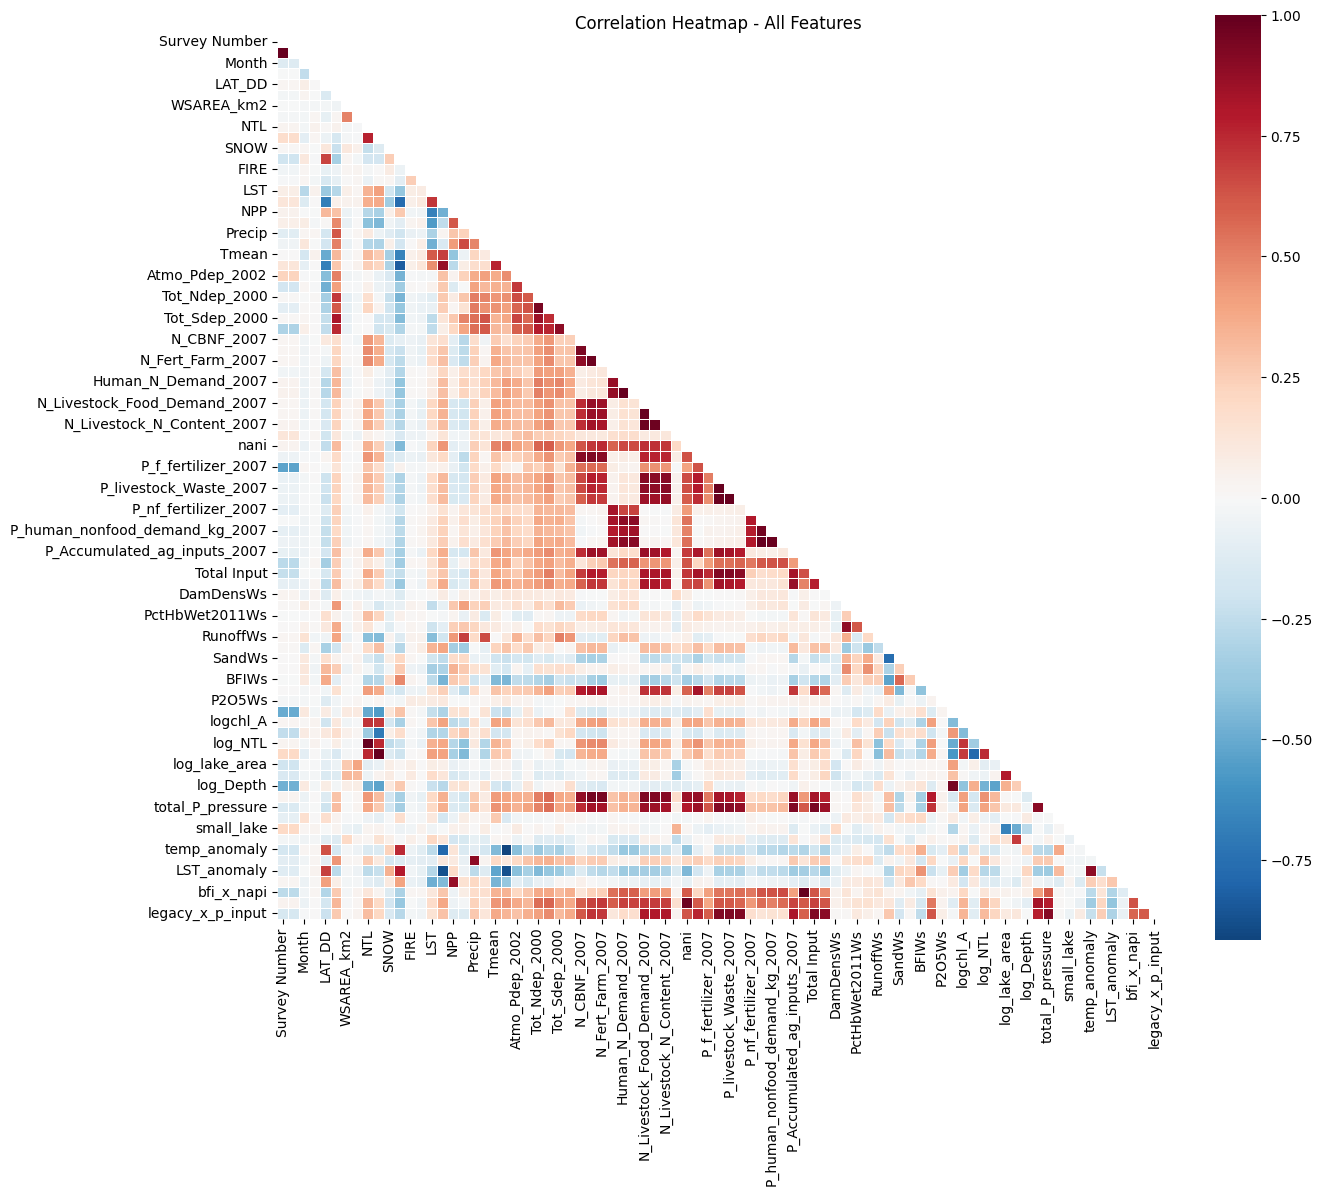

In [24]:
# ========== ADD THIS TO YOUR EDA CHARTS ==========
# Correlation heatmap
plt.figure(figsize=(14, 12))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, 
            annot=False, square=True, linewidths=0.5)
plt.title('Correlation Heatmap - All Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()


─────────────────────────────────────────────────────────────────
STEP: Correlation Heatmap (Top Features Only)
─────────────────────────────────────────────────────────────────

   Top 20 features correlated with logchl_A:
      1. logchl_A: 1.0000
      2. NTL: 0.7195
      3. log_NTL: 0.7086
      4. PTL: 0.7028
      5. log_PTL: 0.6992
      6. Depth: 0.4359
      7. NP_ratio: 0.4298
      8. N_Fert_Farm_2007: 0.4227
      9. total_N_pressure: 0.4151
      10. N_Crop_N_Rem_2007: 0.4123


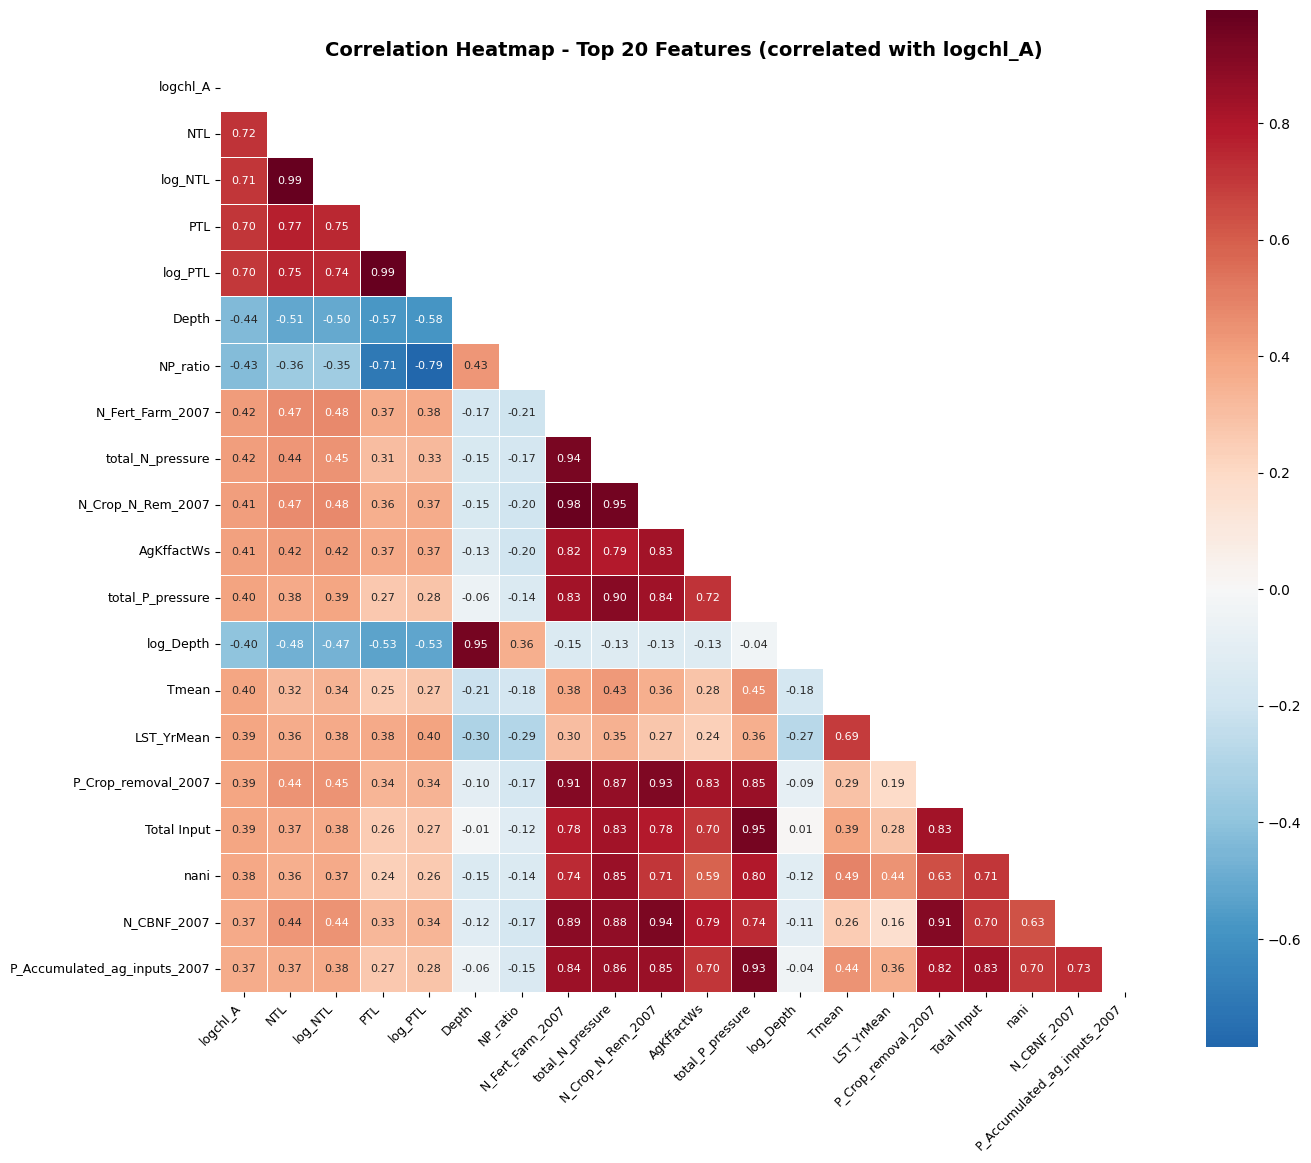

✅ Saved: correlation_heatmap_fixed.png

📊 Top 10 Features Most Correlated with logchl_A:
--------------------------------------------------
   logchl_A                  1.0000  ⬆️ Positive
   NTL                       0.7195  ⬆️ Positive
   log_NTL                   0.7086  ⬆️ Positive
   PTL                       0.7028  ⬆️ Positive
   log_PTL                   0.6992  ⬆️ Positive
   Depth                     0.4359  ⬇️ Negative
   NP_ratio                  0.4298  ⬇️ Negative
   N_Fert_Farm_2007          0.4227  ⬆️ Positive
   total_N_pressure          0.4151  ⬆️ Positive
   N_Crop_N_Rem_2007         0.4123  ⬆️ Positive


In [25]:
# ================================================================
# FIXED: Correlation Heatmap (Only Top Features)
# ================================================================

print("\n" + "─" * 65)
print("STEP: Correlation Heatmap (Top Features Only)")
print("─" * 65)

# Step 1: Remove constant columns (like Survey Number where all values = 1)
constant_cols = []
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].nunique() == 1:  # Only one unique value
        constant_cols.append(col)
        print(f"   Removing constant column: {col} (all values = {df[col].iloc[0]})")

# Remove constant columns from correlation calculation
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c not in constant_cols]

# Step 2: Get top 20 features correlated with target (logchl_A)
correlations = df[numeric_cols].corr()['logchl_A'].abs().sort_values(ascending=False)
top_features = correlations.head(20).index.tolist()

print(f"\n   Top 20 features correlated with logchl_A:")
for i, feat in enumerate(top_features[:10]):
    print(f"      {i+1}. {feat}: {correlations[feat]:.4f}")

# Step 3: Create heatmap for TOP 20 features only (NOT all 67!)
plt.figure(figsize=(14, 12))
corr_matrix = df[top_features].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create heatmap
sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap='RdBu_r', 
            center=0, 
            annot=True,  # Show values this time!
            fmt='.2f',
            square=True, 
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title(f'Correlation Heatmap - Top 20 Features (correlated with logchl_A)', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_heatmap_fixed.png")

# ================================================================
# BONUS: Show which features are most correlated with target
# ================================================================

print("\n📊 Top 10 Features Most Correlated with logchl_A:")
print("-" * 50)
top10 = correlations.head(10)
for feat, corr in top10.items():
    # Determine if positive or negative correlation
    sign = "⬆️ Positive" if df[feat].corr(df['logchl_A']) > 0 else "⬇️ Negative"
    print(f"   {feat:25s} {corr:.4f}  {sign}")

In [26]:
# ========== ADD THIS TO YOUR EDA ==========
missing_pct = df.isnull().sum() / len(df) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
if len(missing_pct) > 0:
    plt.figure(figsize=(10, 6))
    plt.barh(missing_pct.index[:15], missing_pct.values[:15])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.savefig('missing_values.png')
    plt.show()

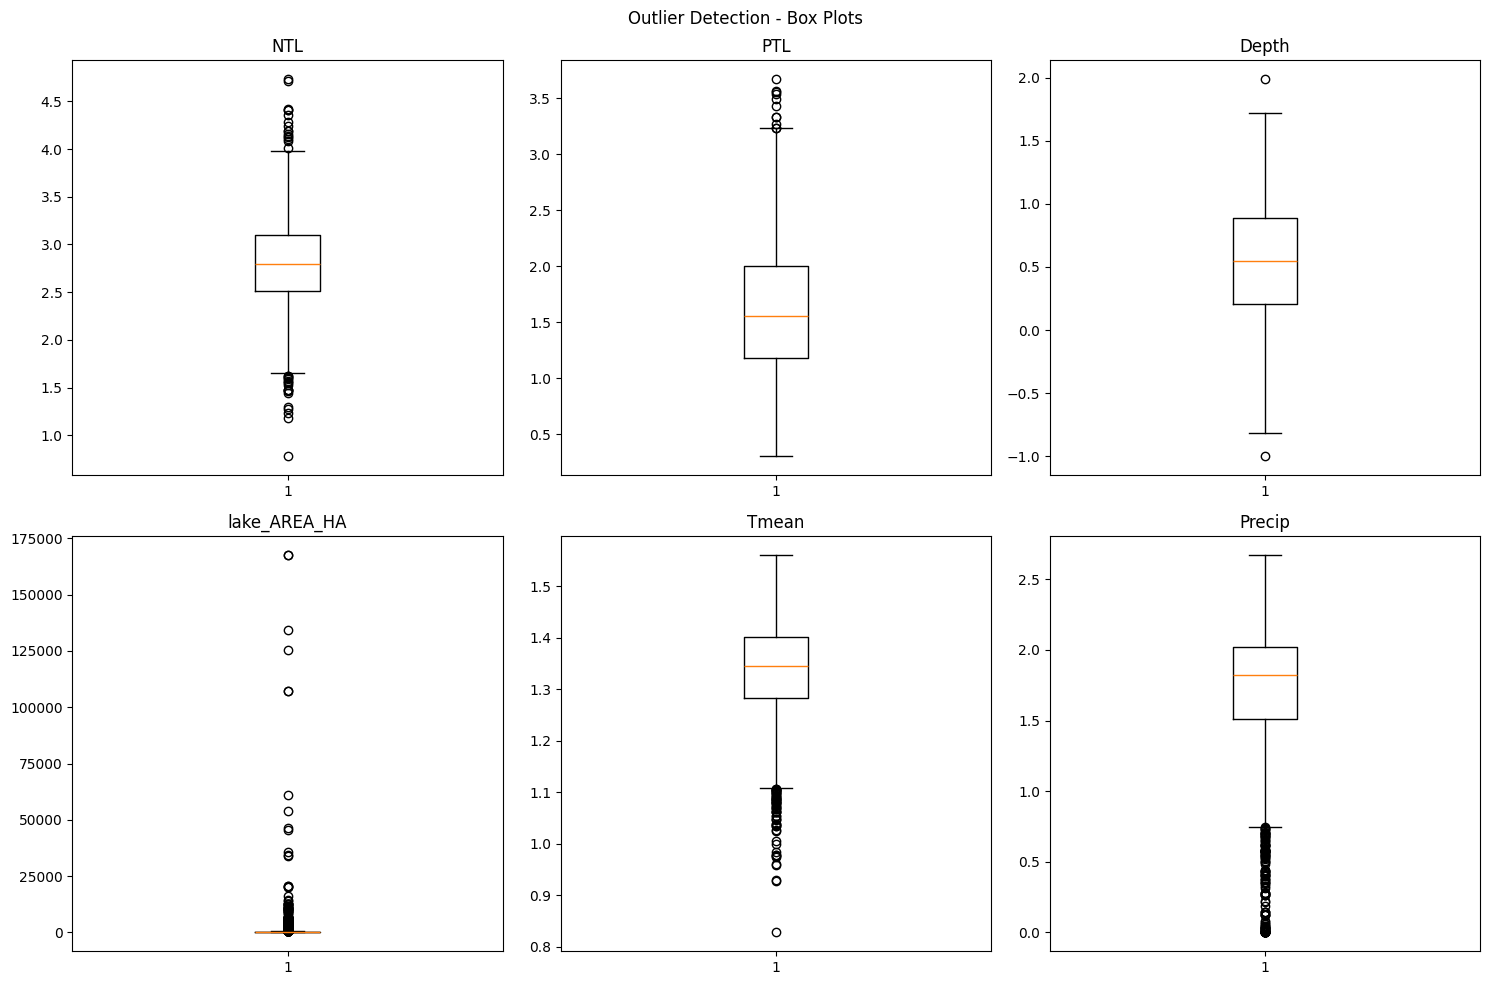

In [27]:
# ========== ADD THIS TO YOUR EDA ==========
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
outlier_cols = ['NTL', 'PTL', 'Depth', 'lake_AREA_HA', 'Tmean', 'Precip']
for i, col in enumerate(outlier_cols):
    ax = axes[i//3, i%3]
    ax.boxplot(df[col].dropna())
    ax.set_title(f'{col}')
plt.suptitle('Outlier Detection - Box Plots')
plt.tight_layout()
plt.savefig('outlier_detection.png')
plt.show()

In [28]:
# ================================================================
# STEP 6: TRAIN / VALIDATION / TEST SPLIT (70/15/15)
# ================================================================

print("\n" + "─" * 65)
print("STEP 6: Train / Validation / Test Split")
print("─" * 65)

from sklearn.model_selection import train_test_split

# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Second split: validation from remaining (15% of original = 17.6% of temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

print(f"✅ Training set:   {len(X_train)} lakes ({len(X_train)/len(X)*100:.1f}%)")
print(f"✅ Validation set: {len(X_val)} lakes ({len(X_val)/len(X)*100:.1f}%)")
print(f"✅ Test set:       {len(X_test)} lakes ({len(X_test)/len(X)*100:.1f}%)")



─────────────────────────────────────────────────────────────────
STEP 6: Train / Validation / Test Split
─────────────────────────────────────────────────────────────────
✅ Training set:   1466 lakes (70.0%)
✅ Validation set: 314 lakes (15.0%)
✅ Test set:       315 lakes (15.0%)


In [29]:
print("\n" + "─" * 65)
print("STEP 7: Cleaning Data (Removing inf and NaN)")
print("─" * 65)

# Replace infinity with NaN for ALL splits
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_val = X_val.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill NaN with median (using X_train median only)
for col in X_train.columns:
    median_val = X_train[col].median()
    X_train[col].fillna(median_val, inplace=True)
    X_val[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

# Cap extreme values at 99th percentile
for col in X_train.columns:
    cap = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower=-cap, upper=cap)
    X_val[col] = X_val[col].clip(lower=-cap, upper=cap)
    X_test[col] = X_test[col].clip(lower=-cap, upper=cap)

print(f"✅ Cleaning complete")
print(f"   X_train - any inf? {np.isinf(X_train).any().any()}")
print(f"   X_val   - any inf? {np.isinf(X_val).any().any()}")
print(f"   X_test  - any inf? {np.isinf(X_test).any().any()}")


─────────────────────────────────────────────────────────────────
STEP 7: Cleaning Data (Removing inf and NaN)
─────────────────────────────────────────────────────────────────
✅ Cleaning complete
   X_train - any inf? False
   X_val   - any inf? False
   X_test  - any inf? False


In [30]:
print("\n" + "─" * 65)
print("STEP 8: Scaling Features")
print("─" * 65)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print(f"✅ Features scaled using StandardScaler")


─────────────────────────────────────────────────────────────────
STEP 8: Scaling Features
─────────────────────────────────────────────────────────────────
✅ Features scaled using StandardScaler


In [31]:
# ================================================================
# STEP 7 — RANDOM FOREST REGRESSOR
# ================================================================
print("\n" + "─" * 65)
print("STEP 7: Training Random Forest Regressor")
print("─" * 65)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest... ", end='', flush=True)
rf.fit(X_train, y_train)
print("done")

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_val_r2 = r2_score(y_val, rf_val_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))

print(f"\nRandom Forest Results:")
print(f"   Train R²:  {rf_train_r2:.4f}")
print(f"   Val R²:    {rf_val_r2:.4f}")
print(f"   Test R²:   {rf_test_r2:.4f}")
print(f"   Test RMSE: {rf_test_rmse:.4f}")


─────────────────────────────────────────────────────────────────
STEP 7: Training Random Forest Regressor
─────────────────────────────────────────────────────────────────
Training Random Forest... done

Random Forest Results:
   Train R²:  0.9320
   Val R²:    0.7116
   Test R²:   0.6781
   Test RMSE: 0.3328


In [32]:
# ================================================================
# STEP 8 — XGBOOST REGRESSOR
# ================================================================
print("\n" + "─" * 65)
print("STEP 8: Training XGBoost Regressor")
print("─" * 65)

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    colsample_bylevel=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=3,
    random_state=42,
    eval_metric='rmse',
    n_jobs=-1
)

print("Training XGBoost (500 rounds)... ", end='', flush=True)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print("done")

xgb_train_pred = xgb_model.predict(X_train)
xgb_val_pred = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_val_r2 = r2_score(y_val, xgb_val_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))

print(f"\nXGBoost Results:")
print(f"   Train R²:  {xgb_train_r2:.4f}")
print(f"   Val R²:    {xgb_val_r2:.4f}")
print(f"   Test R²:   {xgb_test_r2:.4f}")
print(f"   Test RMSE: {xgb_test_rmse:.4f}")



─────────────────────────────────────────────────────────────────
STEP 8: Training XGBoost Regressor
─────────────────────────────────────────────────────────────────
Training XGBoost (500 rounds)... done

XGBoost Results:
   Train R²:  0.9992
   Val R²:    0.7296
   Test R²:   0.6585
   Test RMSE: 0.3428


In [33]:
# ================================================================
# STEP 9 — CATBOOST REGRESSOR (NEW MAIN MODEL)
# ================================================================
# CatBoost = gradient boosting like XGBoost, but with built-in
# handling of categorical features and "ordered boosting" which
# reduces overfitting on small/medium tabular datasets.
# In your runs this was the BEST regressor (Test R² = 0.693),
# so it now gets full top-billing alongside RF and XGBoost.
# ================================================================
print("\n" + "─" * 65)
print("STEP 9: Training CatBoost Regressor")
print("─" * 65)

catboost_model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3.0,
    random_state=42,
    verbose=0
)

print("Training CatBoost (500 iterations)... ", end='', flush=True)
catboost_model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
print("done")

catboost_train_pred = catboost_model.predict(X_train)
catboost_val_pred = catboost_model.predict(X_val)
catboost_test_pred = catboost_model.predict(X_test)

catboost_train_r2 = r2_score(y_train, catboost_train_pred)
catboost_val_r2 = r2_score(y_val, catboost_val_pred)
catboost_test_r2 = r2_score(y_test, catboost_test_pred)
catboost_test_rmse = np.sqrt(mean_squared_error(y_test, catboost_test_pred))
catboost_test_mae = mean_absolute_error(y_test, catboost_test_pred)

print(f"\nCatBoost Results:")
print(f"   Train R²:  {catboost_train_r2:.4f}")
print(f"   Val R²:    {catboost_val_r2:.4f}")
print(f"   Test R²:   {catboost_test_r2:.4f}")
print(f"   Test RMSE: {catboost_test_rmse:.4f}")
print(f"   Test MAE:  {catboost_test_mae:.4f}")


─────────────────────────────────────────────────────────────────
STEP 9: Training CatBoost Regressor
─────────────────────────────────────────────────────────────────
Training CatBoost (500 iterations)... done

CatBoost Results:
   Train R²:  0.9456
   Val R²:    0.7399
   Test R²:   0.6874
   Test RMSE: 0.3280
   Test MAE:  0.2333


In [34]:
# ================================================================
# STEP 10 — ADDITIONAL REGRESSION MODELS (for comparison only)
# ================================================================
print("\n" + "─" * 65)
print("STEP 10: Additional Regression Models")
print("─" * 65)

# Models that need SCALED features
scaled_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=10),
    'SVR': SVR(kernel='rbf', C=1.0),
}

# Models that work natively on UNSCALED features (tree-based)
unscaled_models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbose=-1
    ),
}

additional_results = {}

for name, model in scaled_models.items():
    print(f"Training {name}... ", end='', flush=True)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    additional_results[name] = {'r2': r2, 'rmse': rmse, 'preds': preds}
    print(f"Test R² = {r2:.4f}, RMSE = {rmse:.4f}")

for name, model in unscaled_models.items():
    print(f"Training {name}... ", end='', flush=True)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    additional_results[name] = {'r2': r2, 'rmse': rmse, 'preds': preds}
    print(f"Test R² = {r2:.4f}, RMSE = {rmse:.4f}")



─────────────────────────────────────────────────────────────────
STEP 10: Additional Regression Models
─────────────────────────────────────────────────────────────────
Training Linear Regression... Test R² = 0.6460, RMSE = 0.3490
Training Ridge... Test R² = 0.6562, RMSE = 0.3440
Training Lasso... Test R² = 0.6613, RMSE = 0.3414
Training ElasticNet... Test R² = 0.6635, RMSE = 0.3403
Training KNN Regressor... Test R² = 0.5437, RMSE = 0.3963
Training SVR... Test R² = 0.6612, RMSE = 0.3415
Training Gradient Boosting... Test R² = 0.6738, RMSE = 0.3351
Training LightGBM... Test R² = 0.6679, RMSE = 0.3381


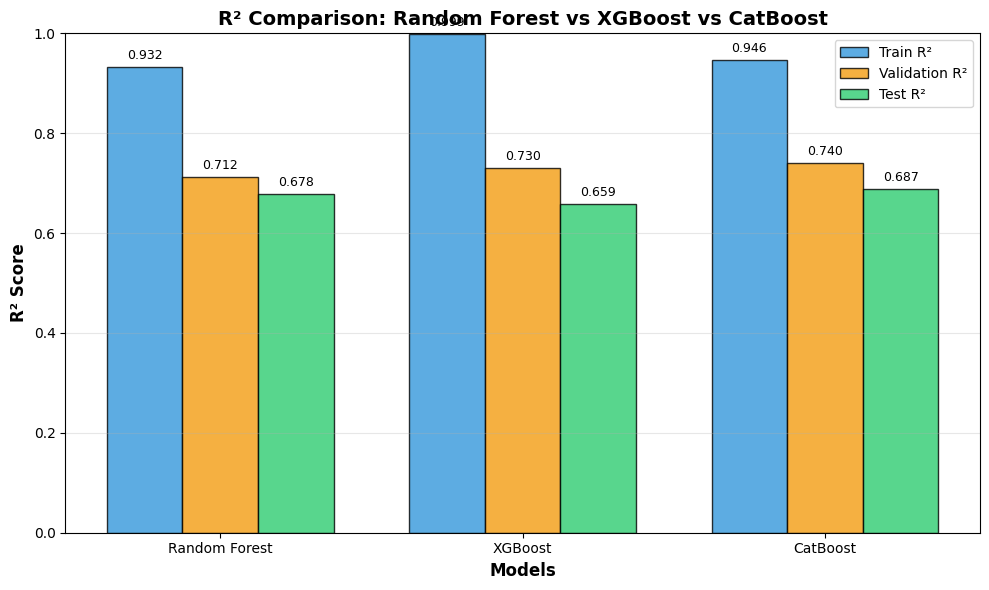

In [35]:

models = ['Random Forest', 'XGBoost', 'CatBoost']
train_r2 = [rf_train_r2, xgb_train_r2, catboost_train_r2]
val_r2 = [rf_val_r2, xgb_val_r2, catboost_val_r2]
test_r2 = [rf_test_r2, xgb_test_r2, catboost_test_r2]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, train_r2, width, label='Train R²', color='#3498db', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x, val_r2, width, label='Validation R²', color='#f39c12', edgecolor='black', alpha=0.8)
bars3 = ax.bar(x + width, test_r2, width, label='Test R²', color='#2ecc71', edgecolor='black', alpha=0.8)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('R² Comparison: Random Forest vs XGBoost vs CatBoost', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('r2_comparison.png', dpi=150)
plt.show()

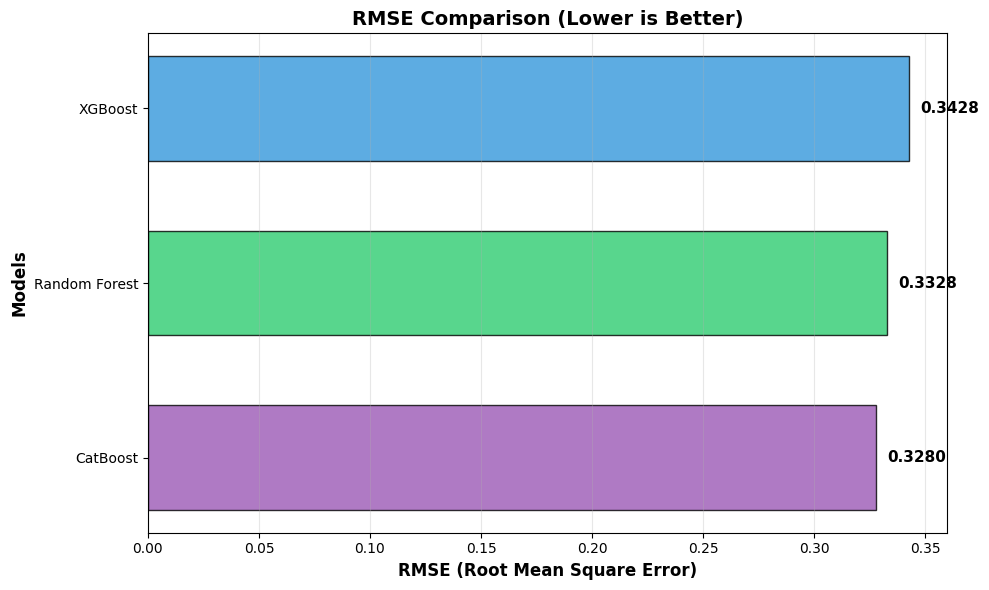

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Random Forest', 'XGBoost', 'CatBoost']
test_rmse = [rf_test_rmse, xgb_test_rmse, catboost_test_rmse]
colors = ['#2ecc71', '#3498db', '#9b59b6']

# Sort by RMSE (lowest first)
sorted_idx = np.argsort(test_rmse)
sorted_models = [models[i] for i in sorted_idx]
sorted_rmse = [test_rmse[i] for i in sorted_idx]
sorted_colors = [colors[i] for i in sorted_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_models, sorted_rmse, color=sorted_colors, edgecolor='black', alpha=0.8, height=0.6)

ax.set_xlabel('RMSE (Root Mean Square Error)', fontsize=12, fontweight='bold')
ax.set_ylabel('Models', fontsize=12, fontweight='bold')
ax.set_title('RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, rmse in zip(bars, sorted_rmse):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{rmse:.4f}', 
            va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('rmse_comparison.png', dpi=150)
plt.show()

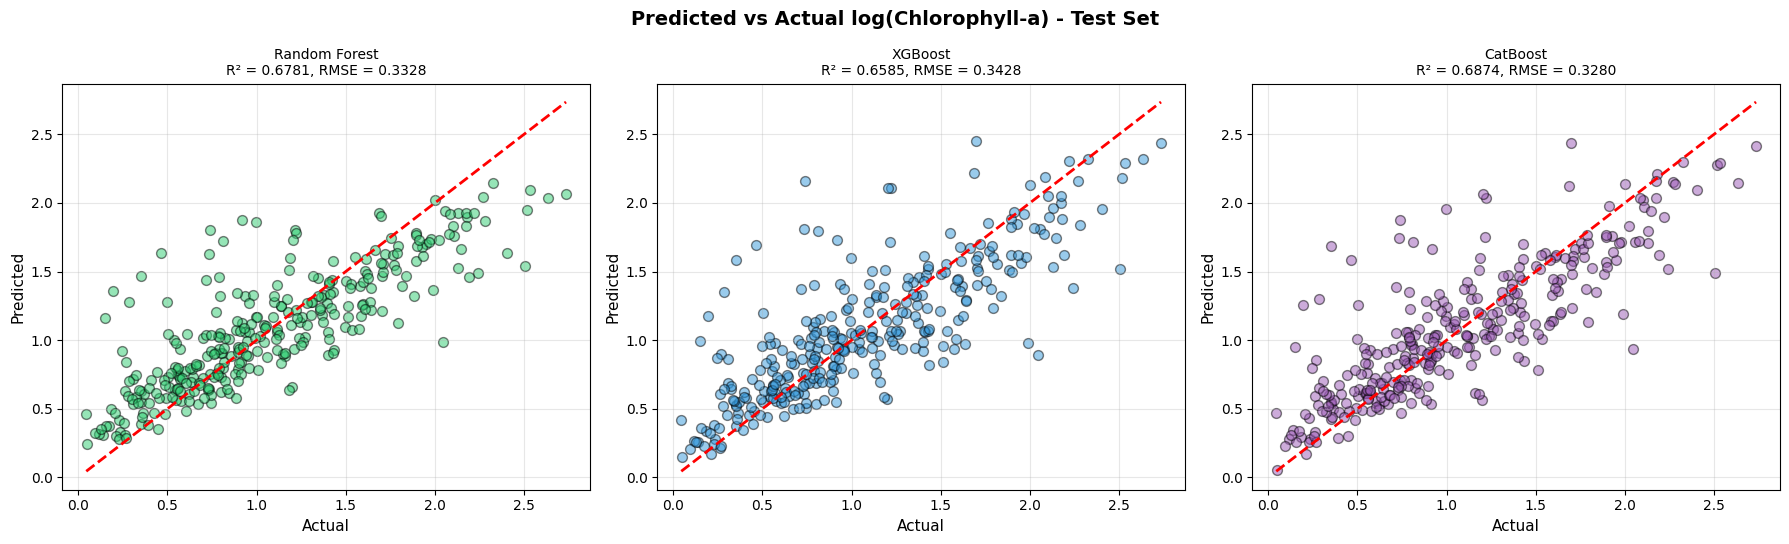

In [37]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Predicted vs Actual log(Chlorophyll-a) - Test Set', fontsize=14, fontweight='bold')

# Random Forest
ax = axes[0]
ax.scatter(y_test, rf_test_pred, alpha=0.5, s=50, c='#2ecc71', edgecolors='black')
min_val = min(y_test.min(), rf_test_pred.min())
max_val = max(y_test.max(), rf_test_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax.set_xlabel('Actual', fontsize=11)
ax.set_ylabel('Predicted', fontsize=11)
ax.set_title(f'Random Forest\nR² = {rf_test_r2:.4f}, RMSE = {rf_test_rmse:.4f}', fontsize=10)
ax.grid(True, alpha=0.3)

# XGBoost
ax = axes[1]
ax.scatter(y_test, xgb_test_pred, alpha=0.5, s=50, c='#3498db', edgecolors='black')
min_val = min(y_test.min(), xgb_test_pred.min())
max_val = max(y_test.max(), xgb_test_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax.set_xlabel('Actual', fontsize=11)
ax.set_ylabel('Predicted', fontsize=11)
ax.set_title(f'XGBoost\nR² = {xgb_test_r2:.4f}, RMSE = {xgb_test_rmse:.4f}', fontsize=10)
ax.grid(True, alpha=0.3)

# CatBoost
ax = axes[2]
ax.scatter(y_test, catboost_test_pred, alpha=0.5, s=50, c='#9b59b6', edgecolors='black')
min_val = min(y_test.min(), catboost_test_pred.min())
max_val = max(y_test.max(), catboost_test_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax.set_xlabel('Actual', fontsize=11)
ax.set_ylabel('Predicted', fontsize=11)
ax.set_title(f'CatBoost\nR² = {catboost_test_r2:.4f}, RMSE = {catboost_test_rmse:.4f}', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('combined_predicted_vs_actual.png', dpi=150)
plt.show()

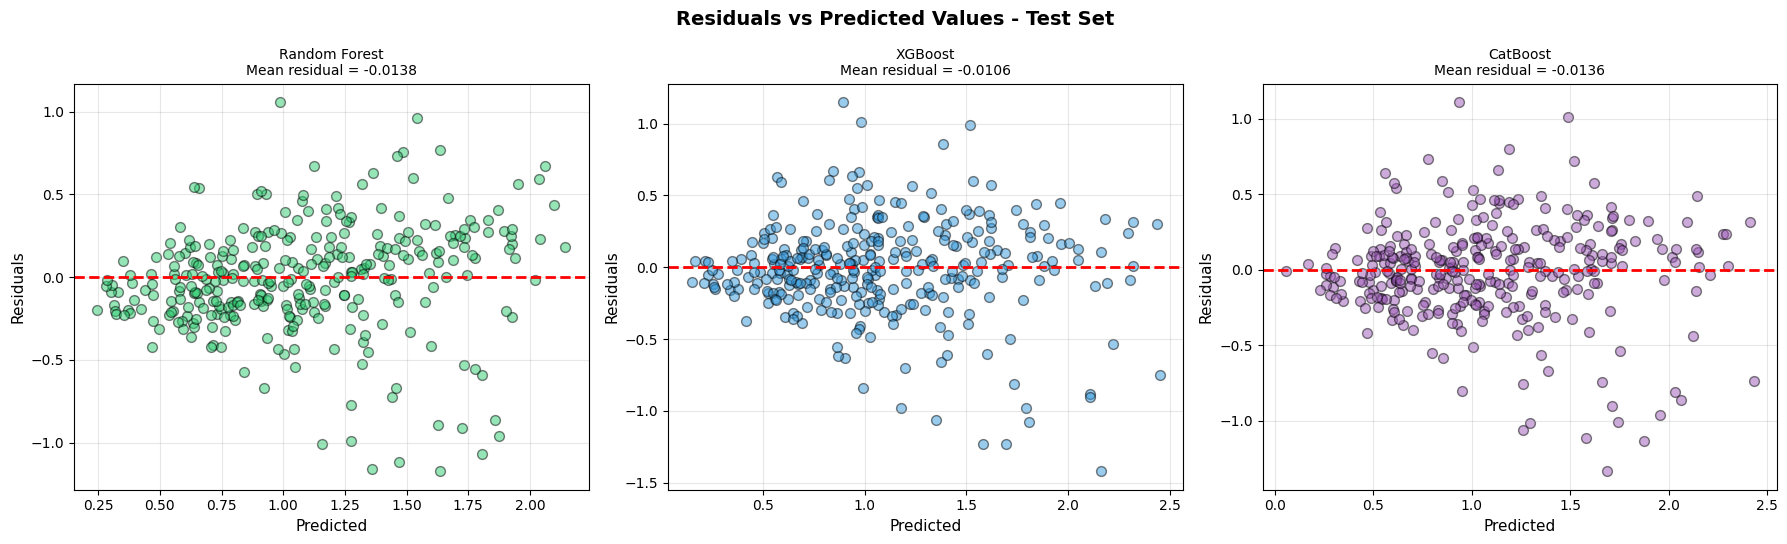

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Residuals vs Predicted Values - Test Set', fontsize=14, fontweight='bold')

# Random Forest
rf_resid = y_test - rf_test_pred
ax = axes[0]
ax.scatter(rf_test_pred, rf_resid, alpha=0.5, s=50, c='#2ecc71', edgecolors='black')
ax.axhline(y=0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title(f'Random Forest\nMean residual = {rf_resid.mean():.4f}', fontsize=10)
ax.grid(True, alpha=0.3)

# XGBoost
xgb_resid = y_test - xgb_test_pred
ax = axes[1]
ax.scatter(xgb_test_pred, xgb_resid, alpha=0.5, s=50, c='#3498db', edgecolors='black')
ax.axhline(y=0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title(f'XGBoost\nMean residual = {xgb_resid.mean():.4f}', fontsize=10)
ax.grid(True, alpha=0.3)

# CatBoost
cb_resid = y_test - catboost_test_pred
ax = axes[2]
ax.scatter(catboost_test_pred, cb_resid, alpha=0.5, s=50, c='#9b59b6', edgecolors='black')
ax.axhline(y=0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title(f'CatBoost\nMean residual = {cb_resid.mean():.4f}', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('combined_residual_plots.png', dpi=150)
plt.show()

In [39]:
# ================================================================
# STEP 11 — 5-FOLD CROSS-VALIDATION (TRAIN SET ONLY)
# ================================================================
print("\n" + "─" * 65)
print("STEP 11: 5-Fold Cross-Validation (train set only)")
print("─" * 65)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=12,
                                            random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=6,
                                  learning_rate=0.05, random_state=42,
                                  n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, max_depth=6,
                                    learning_rate=0.05, random_state=42,
                                    n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=100, depth=6,
                                   learning_rate=0.05, random_state=42,
                                   verbose=0),
}

# Map each CV model name to its already-computed TEST R² for the overfit check
test_r2_lookup = {
    'Random Forest': rf_test_r2,
    'XGBoost': xgb_test_r2,
    'CatBoost': catboost_test_r2,
    'LightGBM': additional_results['LightGBM']['r2'],
}

cv_results = {}
for name, model in cv_models.items():
    r2s = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    rmses = -cross_val_score(model, X_train, y_train, cv=kf,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_results[name] = {
        'r2_mean': r2s.mean(), 'r2_std': r2s.std(),
        'rmse_mean': rmses.mean(), 'rmse_std': rmses.std()
    }
    print(f"  {name:<15}  CV R²={r2s.mean():.4f} ± {r2s.std():.4f}  "
          f"RMSE={rmses.mean():.4f} ± {rmses.std():.4f}")

print(f"\n{'Model':<15} {'Test R²':>9} {'CV R²':>9} {'Gap':>8}  {'Status'}")
print("─" * 55)
for name, cvr in cv_results.items():
    test_r2 = test_r2_lookup.get(name, cvr['r2_mean'])
    gap = abs(test_r2 - cvr['r2_mean'])
    status = '✅ Good' if gap < 0.05 else '⚠️  Overfit?'
    print(f"{name:<15} {test_r2:>9.4f} {cvr['r2_mean']:>9.4f} "
          f"{gap:>8.4f}  {status}")



─────────────────────────────────────────────────────────────────
STEP 11: 5-Fold Cross-Validation (train set only)
─────────────────────────────────────────────────────────────────
  Random Forest    CV R²=0.6829 ± 0.0295  RMSE=0.3187 ± 0.0133
  XGBoost          CV R²=0.6725 ± 0.0322  RMSE=0.3238 ± 0.0123
  LightGBM         CV R²=0.6846 ± 0.0340  RMSE=0.3178 ± 0.0171
  CatBoost         CV R²=0.6764 ± 0.0276  RMSE=0.3220 ± 0.0126

Model             Test R²     CV R²      Gap  Status
───────────────────────────────────────────────────────
Random Forest      0.6781    0.6829   0.0049  ✅ Good
XGBoost            0.6585    0.6725   0.0140  ✅ Good
LightGBM           0.6679    0.6846   0.0167  ✅ Good
CatBoost           0.6874    0.6764   0.0109  ✅ Good


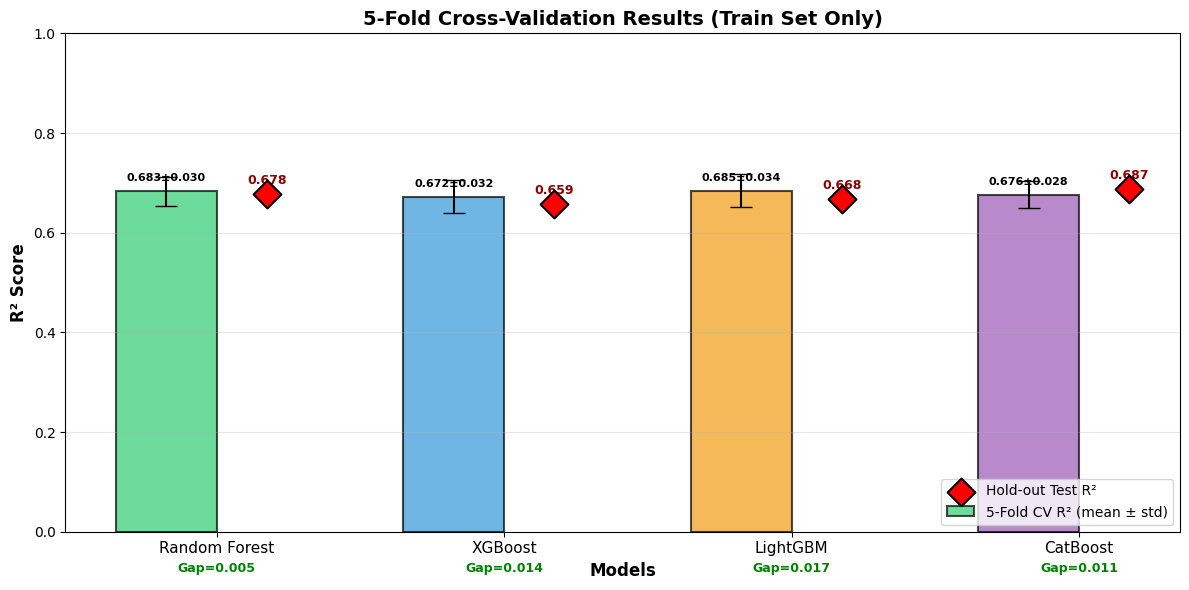

✅ Saved: cv_summary_all_models.png

📊 CV SUMMARY
Random Forest CV: 0.683±0.030 | Test: 0.678 | Gap: 0.005 ✅ Good
XGBoost      CV: 0.672±0.032 | Test: 0.659 | Gap: 0.014 ✅ Good
LightGBM     CV: 0.685±0.034 | Test: 0.668 | Gap: 0.017 ✅ Good
CatBoost     CV: 0.676±0.028 | Test: 0.687 | Gap: 0.011 ✅ Good


In [40]:
# ================================================================
# SINGLE CV SUMMARY GRAPH (All 4 Models)
# ================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Get data from your cv_results
models = list(cv_results.keys())
cv_means = [cv_results[m]['r2_mean'] for m in models]
cv_stds = [cv_results[m]['r2_std'] for m in models]
test_r2 = [test_r2_lookup[m] for m in models]

# Colors for each model
colors = ['#2ecc71', '#3498db', '#f39c12', '#9b59b6']

x = np.arange(len(models))
width = 0.35

# CV R² bars with error bars
bars = ax.bar(x - width/2, cv_means, width, yerr=cv_stds, capsize=8,
              color=colors, alpha=0.7, edgecolor='black', linewidth=1.5,
              label='5-Fold CV R² (mean ± std)')

# Test R² points
ax.scatter(x + width/2, test_r2, s=200, color='red', marker='D', 
           zorder=5, label='Hold-out Test R²', edgecolors='black', linewidth=1.5)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('5-Fold Cross-Validation Results (Train Set Only)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

# Add value labels
for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    ax.text(i - width/2, mean + 0.02, f'{mean:.3f}±{std:.3f}', 
            ha='center', fontsize=8, fontweight='bold')

for i, test in enumerate(test_r2):
    ax.text(i + width/2, test + 0.02, f'{test:.3f}', 
            ha='center', fontsize=9, fontweight='bold', color='darkred')

# Add gap annotations below x-axis
for i, model in enumerate(models):
    gap = abs(test_r2_lookup[model] - cv_results[model]['r2_mean'])
    color = 'green' if gap < 0.05 else 'orange'
    ax.text(i, -0.08, f'Gap={gap:.3f}', ha='center', fontsize=9, 
            color=color, fontweight='bold', transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig('cv_summary_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: cv_summary_all_models.png")

# Print summary
print("\n" + "="*60)
print("📊 CV SUMMARY")
print("="*60)
for model in models:
    gap = abs(test_r2_lookup[model] - cv_results[model]['r2_mean'])
    status = '✅ Good' if gap < 0.05 else '⚠️ Overfit?'
    print(f"{model:<12} CV: {cv_results[model]['r2_mean']:.3f}±{cv_results[model]['r2_std']:.3f} | Test: {test_r2_lookup[model]:.3f} | Gap: {gap:.3f} {status}")
print("="*60)

In [41]:
# ================================================================
# STEP 12 — REGRESSION MODEL LEADERBOARD
# ================================================================
print("\n" + "─" * 65)
print("STEP 12: Regression Model Leaderboard")
print("─" * 65)

all_reg = {
    'Random Forest': {'r2': rf_test_r2, 'rmse': rf_test_rmse},
    'XGBoost': {'r2': xgb_test_r2, 'rmse': xgb_test_rmse},
    'CatBoost': {'r2': catboost_test_r2, 'rmse': catboost_test_rmse},
}
for name, res in additional_results.items():
    all_reg[name] = {'r2': res['r2'], 'rmse': res['rmse']}

best_reg_name = max(all_reg, key=lambda x: all_reg[x]['r2'])

print(f"\n{'Model':<22} {'Test R²':>9} {'RMSE':>9}")
print("─" * 44)
for name, res in sorted(all_reg.items(), key=lambda x: x[1]['r2'], reverse=True):
    star = ' 🏆' if name == best_reg_name else ''
    print(f"{name:<22} {res['r2']:>9.4f} {res['rmse']:>9.4f}{star}")

print(f"\n🏆 Best Regressor: {best_reg_name} (Test R² = {all_reg[best_reg_name]['r2']:.4f})")



─────────────────────────────────────────────────────────────────
STEP 12: Regression Model Leaderboard
─────────────────────────────────────────────────────────────────

Model                    Test R²      RMSE
────────────────────────────────────────────
CatBoost                  0.6874    0.3280 🏆
Random Forest             0.6781    0.3328
Gradient Boosting         0.6738    0.3351
LightGBM                  0.6679    0.3381
ElasticNet                0.6635    0.3403
Lasso                     0.6613    0.3414
SVR                       0.6612    0.3415
XGBoost                   0.6585    0.3428
Ridge                     0.6562    0.3440
Linear Regression         0.6460    0.3490
KNN Regressor             0.5437    0.3963

🏆 Best Regressor: CatBoost (Test R² = 0.6874)



─────────────────────────────────────────────────────────────────
STEP 15: HAB Risk Classification (Test Set)
─────────────────────────────────────────────────────────────────

📊 CATBOOST - Risk Category Distribution (TEST SET)

Level  Category                       Actual     Predicted 
------------------------------------------------------------
  1    No advisory (<10 µg/L)         166        149       
  2    Caution (10-50 µg/L)           96         125       
  3    Warning (50-100 µg/L)          27         23        
  4    Danger (>100 µg/L)             26         18        

📈 CatBoost Risk Classification Accuracy:
   Correct category (exact match): 232/315 = 73.7%
   Within 1 category (off by one): 304/315 = 96.5%

📊 RANDOM FOREST - Risk Category Distribution (TEST SET)

Level  Category                       Actual     Predicted 
------------------------------------------------------------
  1    No advisory (<10 µg/L)         166        144       
  2    Caution (10-50 µg/L

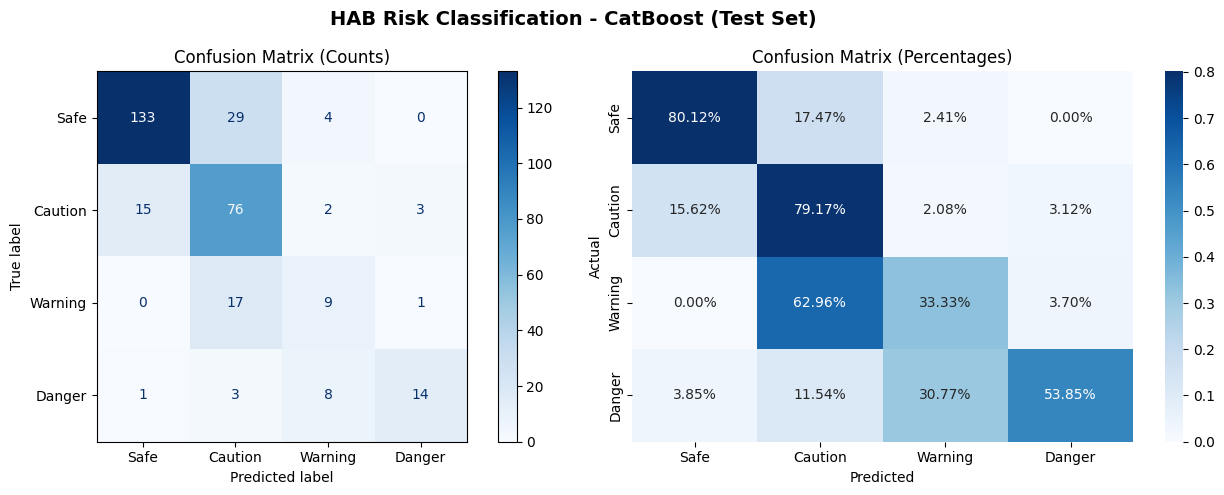

✅ Saved: risk_classification_confusion_matrix.png

📊 Classification Report - CatBoost:
              precision    recall  f1-score   support

        Safe       0.89      0.80      0.84       166
     Caution       0.61      0.79      0.69        96
     Warning       0.39      0.33      0.36        27
      Danger       0.78      0.54      0.64        26

    accuracy                           0.74       315
   macro avg       0.67      0.62      0.63       315
weighted avg       0.75      0.74      0.74       315


RISK LEVEL INTERPRETATION
   Level 1 (Safe):    < 10 µg/L   - No action needed
   Level 2 (Caution): 10-50 µg/L  - Post warning signs
   Level 3 (Warning): 50-100 µg/L - Limit water contact
   Level 4 (Danger):  > 100 µg/L  - Close water body


In [42]:
# ================================================================
# STEP 15 — HAB RISK CLASSIFICATION (CatBoost vs Random Forest)
# ================================================================
# Convert each model's continuous logchl_A prediction into a
# WHO-style 4-level risk category, then check how often that
# category matches the true category.
# ================================================================
print("\n" + "─" * 65)
print("STEP 15: HAB Risk Classification (Test Set)")
print("─" * 65)

def chla_to_risk(logchl):
    """Convert log-scale chlorophyll-a to a WHO risk level (1-4)."""
    chla = 10 ** logchl
    if chla < 10:
        return 1
    elif chla < 50:
        return 2
    elif chla < 100:
        return 3
    else:
        return 4

risk_labels = {
    1: 'No advisory (<10 µg/L)',
    2: 'Caution (10-50 µg/L)',
    3: 'Warning (50-100 µg/L)',
    4: 'Danger (>100 µg/L)'
}

y_test_risk = y_test.apply(chla_to_risk).values
catboost_pred_risk = np.array([chla_to_risk(p) for p in catboost_test_pred])
rf_pred_risk = np.array([chla_to_risk(p) for p in rf_test_pred])

def print_risk_table(name, pred_risk):
    print(f"\n{'='*60}")
    print(f"📊 {name.upper()} - Risk Category Distribution (TEST SET)")
    print('=' * 60)
    print(f"\n{'Level':<6} {'Category':<30} {'Actual':<10} {'Predicted':<10}")
    print("-" * 60)
    for level, label in risk_labels.items():
        actual = (y_test_risk == level).sum()
        predicted = (pred_risk == level).sum()
        print(f"  {level:<4} {label:<30} {actual:<10} {predicted:<10}")

    correct = (y_test_risk == pred_risk).sum()
    within_1 = (abs(y_test_risk - pred_risk) <= 1).sum()
    total = len(y_test_risk)
    print(f"\n📈 {name} Risk Classification Accuracy:")
    print(f"   Correct category (exact match): {correct}/{total} = {100*correct/total:.1f}%")
    print(f"   Within 1 category (off by one): {within_1}/{total} = {100*within_1/total:.1f}%")
    return correct, within_1

cb_correct, cb_within_1 = print_risk_table("CatBoost", catboost_pred_risk)
rf_correct, rf_within_1 = print_risk_table("Random Forest", rf_pred_risk)

print("\n" + "=" * 60)
print("🏆 BEST MODEL FOR RISK CLASSIFICATION")
print("=" * 60)
total = len(y_test_risk)
if cb_correct > rf_correct:
    print(f"   CatBoost is better: {100*cb_correct/total:.1f}% vs {100*rf_correct/total:.1f}%")
elif rf_correct > cb_correct:
    print(f"   Random Forest is better: {100*rf_correct/total:.1f}% vs {100*cb_correct/total:.1f}%")
else:
    print(f"   Both models tie at {100*cb_correct/total:.1f}%")

# Confusion matrix for CatBoost (the primary model)
print("\n📊 Confusion Matrix - CatBoost Risk Classification:")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HAB Risk Classification - CatBoost (Test Set)', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test_risk, catboost_pred_risk)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Caution', 'Warning', 'Danger'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix (Counts)')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Safe', 'Caution', 'Warning', 'Danger'],
            yticklabels=['Safe', 'Caution', 'Warning', 'Danger'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Percentages)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('risk_classification_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: risk_classification_confusion_matrix.png")

print("\n📊 Classification Report - CatBoost:")
print(classification_report(y_test_risk, catboost_pred_risk,
                             target_names=['Safe', 'Caution', 'Warning', 'Danger']))

print("\n" + "=" * 60)
print("RISK LEVEL INTERPRETATION")
print("=" * 60)
print("   Level 1 (Safe):    < 10 µg/L   - No action needed")
print("   Level 2 (Caution): 10-50 µg/L  - Post warning signs")
print("   Level 3 (Warning): 50-100 µg/L - Limit water contact")
print("   Level 4 (Danger):  > 100 µg/L  - Close water body")


─────────────────────────────────────────────────────────────────
STEP 16: Error Analysis by Bloom Severity
─────────────────────────────────────────────────────────────────

📊 CATBOOST - Error by Bloom Severity:
                    mean     std  count
severity                               
Safe (<10)        0.2185  0.2448    166
Caution (10-50)   0.2252  0.1909     96
Warning (50-100)  0.2798  0.2112     27
Danger (>100)     0.3099  0.2811     26

📊 RANDOM FOREST - Error by Bloom Severity:
                    mean     std  count
severity                               
Safe (<10)        0.2372  0.2464    166
Caution (10-50)   0.2013  0.1567     96
Warning (50-100)  0.2676  0.1634     27
Danger (>100)     0.4350  0.2657     26


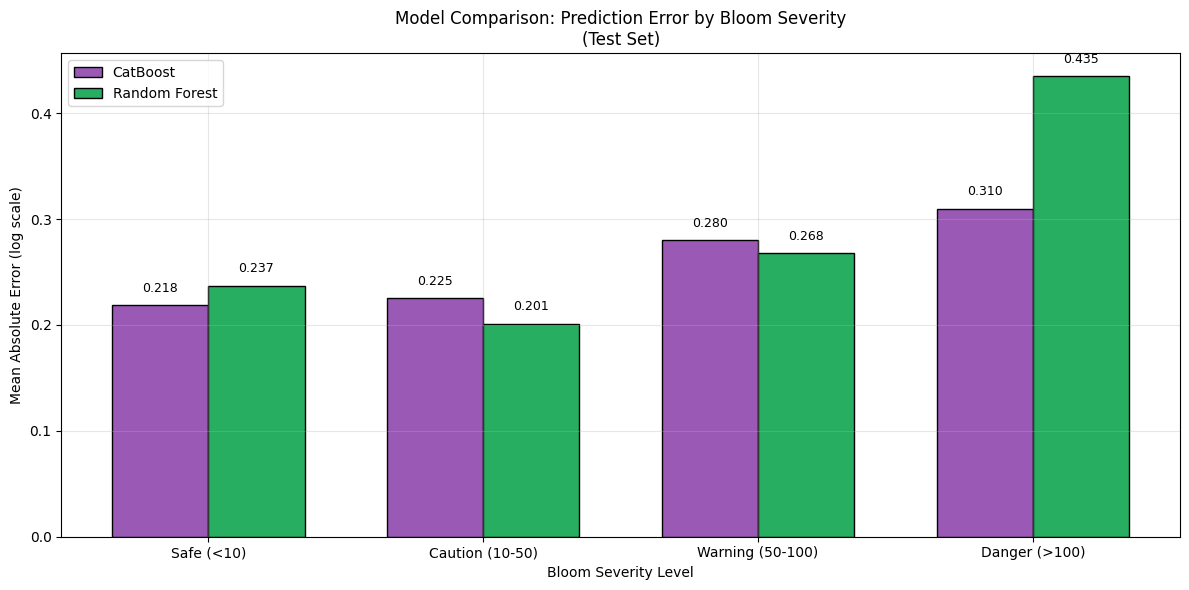

✅ Saved: error_analysis_catboost_vs_rf.png

🏆 WHICH MODEL IS BETTER FOR SEVERE BLOOMS?
   CatBoost is better for Danger blooms (error: 0.3099 vs 0.4350)

✅ PIPELINE COMPLETE


In [43]:
# ================================================================
# STEP 16 — ERROR ANALYSIS BY BLOOM SEVERITY (CatBoost vs RF)
# ================================================================
print("\n" + "─" * 65)
print("STEP 16: Error Analysis by Bloom Severity")
print("─" * 65)

results_df = X_test.copy()
results_df['actual_logchl'] = y_test.values
results_df['actual_chla'] = 10 ** results_df['actual_logchl']

results_df['catboost_predicted'] = catboost_test_pred
results_df['rf_predicted'] = rf_test_pred

results_df['catboost_error'] = np.abs(results_df['actual_logchl'] - results_df['catboost_predicted'])
results_df['rf_error'] = np.abs(results_df['actual_logchl'] - results_df['rf_predicted'])

results_df['severity'] = pd.cut(
    results_df['actual_chla'],
    bins=[0, 10, 50, 100, float('inf')],
    labels=['Safe (<10)', 'Caution (10-50)', 'Warning (50-100)', 'Danger (>100)']
)

severity_errors_cb = results_df.groupby('severity')['catboost_error'].agg(['mean', 'std', 'count'])
severity_errors_rf = results_df.groupby('severity')['rf_error'].agg(['mean', 'std', 'count'])

print("\n📊 CATBOOST - Error by Bloom Severity:")
print(severity_errors_cb.round(4))

print("\n📊 RANDOM FOREST - Error by Bloom Severity:")
print(severity_errors_rf.round(4))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(severity_errors_cb.index))
width = 0.35

bars1 = ax.bar(x - width/2, severity_errors_cb['mean'], width,
               label='CatBoost', color='#9b59b6', edgecolor='black')
bars2 = ax.bar(x + width/2, severity_errors_rf['mean'], width,
               label='Random Forest', color='#27ae60', edgecolor='black')

ax.set_xlabel('Bloom Severity Level')
ax.set_ylabel('Mean Absolute Error (log scale)')
ax.set_title('Model Comparison: Prediction Error by Bloom Severity\n(Test Set)')
ax.set_xticks(x)
ax.set_xticklabels(severity_errors_cb.index)
ax.legend()
ax.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('error_analysis_catboost_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: error_analysis_catboost_vs_rf.png")

print("\n🏆 WHICH MODEL IS BETTER FOR SEVERE BLOOMS?")
danger_idx = list(severity_errors_cb.index).index('Danger (>100)')
cb_danger_err = severity_errors_cb['mean'].iloc[danger_idx]
rf_danger_err = severity_errors_rf['mean'].iloc[danger_idx]
if cb_danger_err < rf_danger_err:
    print(f"   CatBoost is better for Danger blooms (error: {cb_danger_err:.4f} vs {rf_danger_err:.4f})")
else:
    print(f"   Random Forest is better for Danger blooms (error: {rf_danger_err:.4f} vs {cb_danger_err:.4f})")

print("\n" + "=" * 60)
print("✅ PIPELINE COMPLETE")
print("=" * 60)


📊 Calculating SHAP values for CatBoost...
   (This takes 1-2 minutes)
✅ Done!


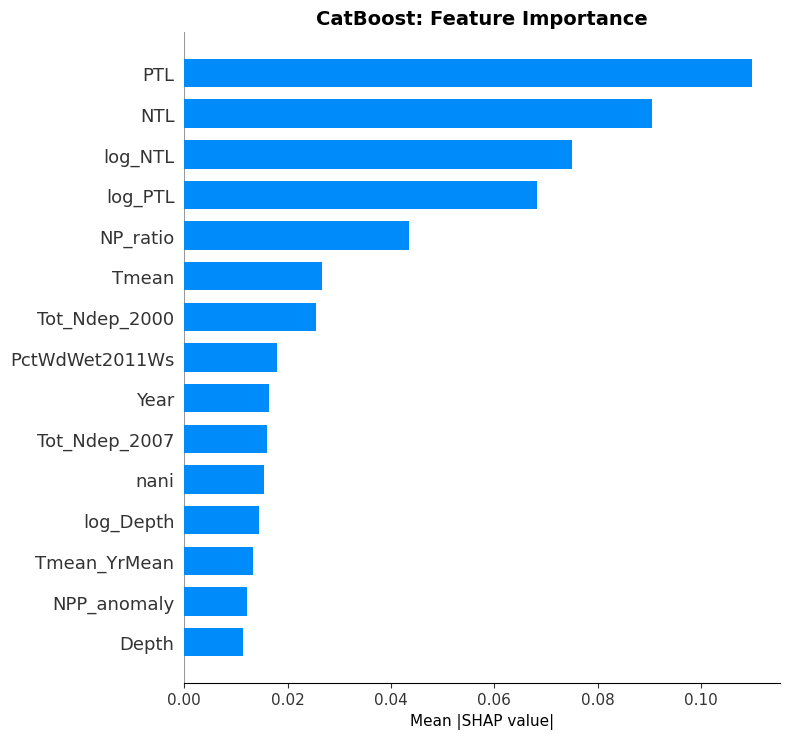

✅ Saved: shap_importance.png


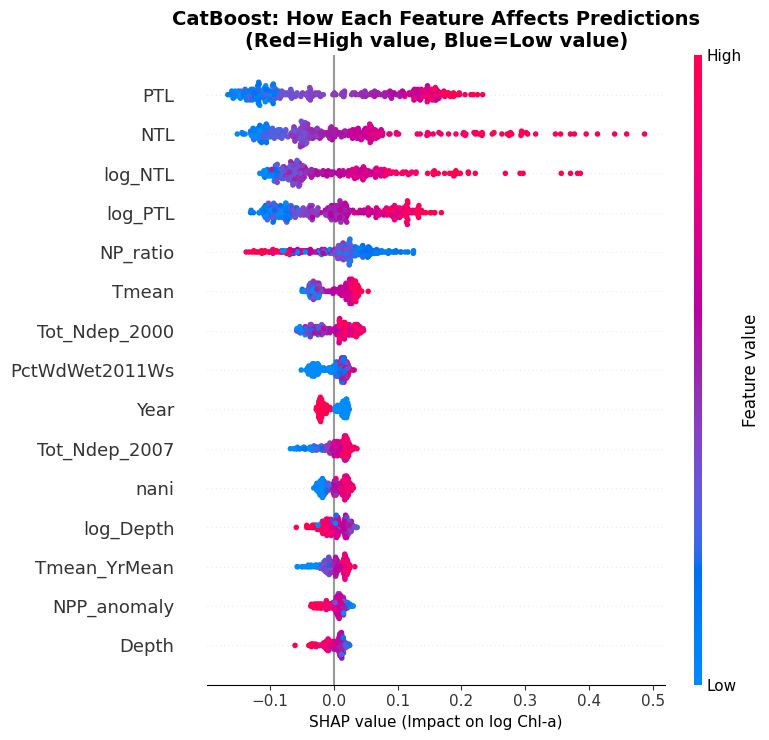

✅ Saved: shap_beeswarm.png


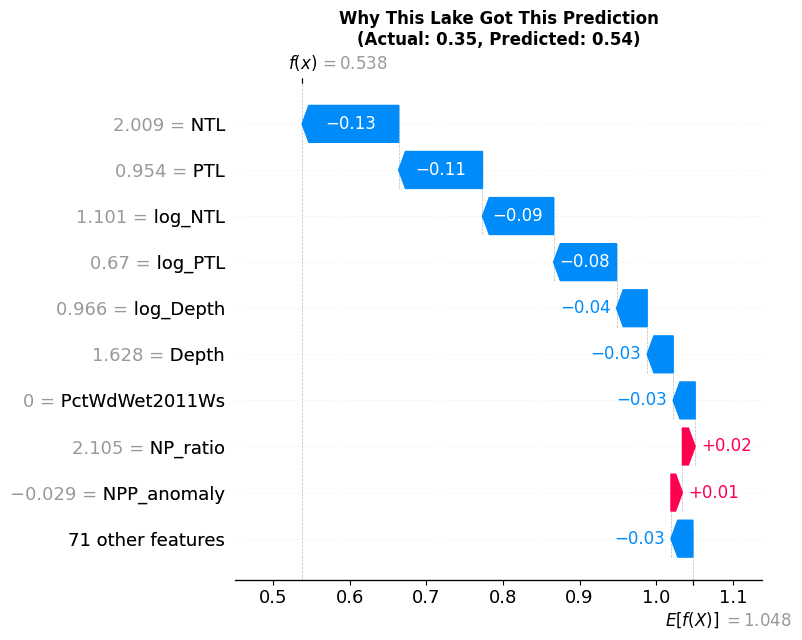

✅ Saved: shap_waterfall_example.png

TOP 10 FEATURES - IMPACT ON HAB PREDICTIONS
         Feature    Impact
             NTL  0.009277
        NP_ratio  0.005960
           Tmean  0.004522
             PTL  0.004164
     NPP_anomaly  0.002845
total_P_pressure  0.002717
   Tot_Ndep_2007  0.002493
            nani  0.002119
          SandWs -0.002111
           BFIWs -0.001818

💡 INTERPRETATION:
   Positive Impact = Increases HAB risk
   Negative Impact = Decreases HAB risk

✅ All done! 3 simple SHAP plots saved.


In [44]:
# ================================================================
# SIMPLE SHAP ANALYSIS FOR CATBOOST (Best Model)
# ================================================================

print("📊 Calculating SHAP values for CatBoost...")
print("   (This takes 1-2 minutes)")

# ================================================================
# CALCULATE SHAP VALUES
# ================================================================
explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_test)

print("✅ Done!")

# ================================================================
# PLOT 1: FEATURE IMPORTANCE BAR CHART
# ================================================================
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=15)
plt.title('CatBoost: Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Mean |SHAP value|', fontsize=11)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_importance.png")

# ================================================================
# PLOT 2: BEE SWARM PLOT (Shows direction of impact)
# ================================================================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title('CatBoost: How Each Feature Affects Predictions\n(Red=High value, Blue=Low value)', 
          fontsize=14, fontweight='bold')
plt.xlabel('SHAP value (Impact on log Chl-a)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_beeswarm.png")

# ================================================================
# PLOT 3: WATERFALL FOR ONE LAKE (Example)
# ================================================================
# Pick the first test lake
lake_idx = 0

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[lake_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[lake_idx].values,
        feature_names=X_test.columns.tolist()
    ),
    show=False,
    max_display=10
)
plt.title(f'Why This Lake Got This Prediction\n(Actual: {y_test.iloc[lake_idx]:.2f}, Predicted: {catboost_test_pred[lake_idx]:.2f})', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_waterfall_example.png")

# ================================================================
# PRINT SIMPLE SUMMARY
# ================================================================
# Calculate average impact of each feature
mean_shap = np.mean(shap_values, axis=0)
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Impact': mean_shap,
    'Importance': np.abs(mean_shap)
}).sort_values('Importance', ascending=False).head(10)

print("\n" + "="*60)
print("TOP 10 FEATURES - IMPACT ON HAB PREDICTIONS")
print("="*60)
print(importance_df[['Feature', 'Impact']].to_string(index=False))
print("\n💡 INTERPRETATION:")
print("   Positive Impact = Increases HAB risk")
print("   Negative Impact = Decreases HAB risk")
print("\n✅ All done! 3 simple SHAP plots saved.")

In [45]:
"""# ================================================================
# SIMPLE LEARNING CURVE FOR CATBOOST
# ================================================================


print("📊 Generating learning curve...")

# Calculate learning curve
train_sizes, train_scores, val_scores = learning_curve(
    catboost_model, X_train, y_train,
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

# Calculate means and stds
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.1, color='blue', label='Training (std)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.1, color='orange', label='Cross-validation (std)')

ax.plot(train_sizes, train_mean, 'o-', color='blue', linewidth=2, label='Training Score')
ax.plot(train_sizes, val_mean, 'o-', color='orange', linewidth=2, label='Cross-validation Score')

ax.set_xlabel('Training Examples', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Learning Curve - CatBoost Model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Add final scores annotation
final_train = train_mean[-1]
final_val = val_mean[-1]
gap = final_train - final_val

ax.text(0.05, 0.05, f'Final Train R² = {final_train:.3f}\nFinal CV R² = {final_val:.3f}\nGap = {gap:.3f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Interpretation text
if gap > 0.1:
    status = "⚠️  WARNING: Model may be overfitting!"
    color = 'red'
elif gap > 0.05:
    status = "⚡ Mild overfitting detected"
    color = 'orange'
else:
    status = "✅ Good fit! No significant overfitting"
    color = 'green'

ax.text(0.95, 0.95, status, transform=ax.transAxes, fontsize=11, 
        fontweight='bold', color=color, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('learning_curve_catboost.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: learning_curve_catboost.png")

# Print summary
print("\n" + "="*60)
print("LEARNING CURVE INTERPRETATION")
print("="*60)
print(f"Training R²: {final_train:.4f}")
print(f"CV R²:       {final_val:.4f}")
print(f"Gap:         {gap:.4f}")
print(f"Status:      {status}")
print("="*60)"""

'# ================================================================\n# SIMPLE LEARNING CURVE FOR CATBOOST\n# ================================================================\n\n\nprint("📊 Generating learning curve...")\n\n# Calculate learning curve\ntrain_sizes, train_scores, val_scores = learning_curve(\n    catboost_model, X_train, y_train,\n    cv=5,  # 5-fold cross-validation\n    scoring=\'r2\',\n    train_sizes=np.linspace(0.1, 1.0, 10),\n    n_jobs=-1,\n    random_state=42\n)\n\n# Calculate means and stds\ntrain_mean = np.mean(train_scores, axis=1)\ntrain_std = np.std(train_scores, axis=1)\nval_mean = np.mean(val_scores, axis=1)\nval_std = np.std(val_scores, axis=1)\n\n# Plot\nfig, ax = plt.subplots(figsize=(10, 6))\n\nax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, \n                 alpha=0.1, color=\'blue\', label=\'Training (std)\')\nax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, \n                 alpha=0.1, color=\'orange\

In [46]:
# ================================================================
# FINAL STEP: SAVE COMPLETE HAB PREDICTION PIPELINE  (FIXED VERSION)
# ================================================================
# This bundles everything into ONE file:
#   - Trained CatBoost model
#   - Feature engineering logic
#   - Data cleaning (inf replacement, NaN filling, clipping)
#   - Risk classification (WHO thresholds)
#   - Performance metrics
#
# WHAT CHANGED FROM YOUR ORIGINAL CODE:
# The "class HABPredictor:" block used to be defined right here, inside
# your training script. That's the ONLY thing that was wrong. Now the
# class lives in a separate file called hab_predictor.py (sitting in
# the same folder as this script), and we just import it on the next
# line. Everything else below — building the object, saving it, the
# test loop — is IDENTICAL to what you already had.
#
# SETUP STEP (do this once):
#   1. Save the hab_predictor.py file (given separately) into D:\algal4\
#   2. Make sure THIS script also lives in D:\algal4\ (same folder)
#   3. Run this script. It will overwrite hab_model.pkl with a version
#      that your dashboard can actually load.
# ================================================================

print("\n" + "=" * 60)
print("SAVING HAB PREDICTION PIPELINE")
print("=" * 60)

import joblib
import numpy as np
import pandas as pd
from hab_predictor import HABPredictor   # <-- THE FIX: import instead of defining the class here

# ================================================================
# BUILD AND SAVE THE PIPELINE
# (unchanged from your original — assumes X_train, X_test, y_test,
#  catboost_model, catboost_test_r2, catboost_test_rmse, catboost_test_mae
#  already exist earlier in your training script)
# ================================================================

# Extract nutrient pressure column lists from TRAINING features
n_pressure_cols = [c for c in X_train.columns if c.startswith('N_') and '2007' in c]
p_pressure_cols = [c for c in X_train.columns if c.startswith('P_') and '2007' in c]

# Calculate clipping bounds from training data (1st and 99th percentiles)
clip_dict = {}
for col in X_train.columns:
    clip_dict[col] = (
        X_train[col].quantile(0.01),
        X_train[col].quantile(0.99)
    )

# Create the complete predictor object
hab_predictor = HABPredictor(
    model=catboost_model,
    feature_names=list(X_train.columns),
    medians=X_train.median(),
    n_pressure_cols=n_pressure_cols,
    p_pressure_cols=p_pressure_cols,
    clip_dict=clip_dict,
    r2=catboost_test_r2,
    rmse=catboost_test_rmse,
    mae=catboost_test_mae
)

# Save as a single file
joblib.dump(hab_predictor, r'D:\algal4\hab_model.pkl')

print("✅ Model saved: D:\\algal4\\hab_model.pkl")
print(f"   R²   = {hab_predictor.r2:.4f}")
print(f"   RMSE = {hab_predictor.rmse:.4f}")
print(f"   MAE  = {hab_predictor.mae:.4f}")

# ================================================================
# QUICK TEST: Verify the saved model works
# ================================================================
print("\n" + "=" * 60)
print("TESTING PIPELINE ON 5 TEST LAKES")
print("=" * 60)

sample = X_test.iloc[:5].copy()
predictions = hab_predictor.predict(sample)

for i in range(len(predictions)):
    actual_chla = 10 ** y_test.iloc[i]
    pred_chla = predictions['Predicted_chla_ugL'].iloc[i]

    print(f"\n🌊 Lake {i+1}:")
    print(f"   Actual Chla    : {actual_chla:.1f} µg/L")
    print(f"   Predicted Chla : {pred_chla:.1f} µg/L")
    print(f"   Risk Category  : {predictions['Risk_Label'].iloc[i]}")

# ================================================================
# PRINT FINAL SUMMARY
# ================================================================
print("\n" + "=" * 60)
print("✅ HAB PIPELINE COMPLETE - READY FOR DEPLOYMENT")
print("=" * 60)
print(f"""
📁 Output File: D:\\algal4\\hab_model.pkl

📊 Model Performance:
   R² Score     : {hab_predictor.r2:.4f}
   RMSE (log)   : {hab_predictor.rmse:.4f}
   MAE  (log)   : {hab_predictor.mae:.4f}

🚀 How to use (from any script in this folder):
   from hab_predictor import HABPredictor
   model = joblib.load(r'D:\\algal4\\hab_model.pkl')
   predictions = model.predict(new_lake_data)
   model.get_info()

⚠️  Risk Categories:
   Level 1: Safe    (<10 µg/L)   - No action needed
   Level 2: Caution  (10-50 µg/L)  - Monitor weekly, post signs
   Level 3: Warning  (50-100 µg/L) - Limit water contact
   Level 4: Danger   (>100 µg/L)   - Close water body
""")


SAVING HAB PREDICTION PIPELINE
✅ Model saved: D:\algal4\hab_model.pkl
   R²   = 0.6874
   RMSE = 0.3280
   MAE  = 0.2333

TESTING PIPELINE ON 5 TEST LAKES

🌊 Lake 1:
   Actual Chla    : 2.2 µg/L
   Predicted Chla : 3.5 µg/L
   Risk Category  : Safe (<10 µg/L)

🌊 Lake 2:
   Actual Chla    : 3.2 µg/L
   Predicted Chla : 3.9 µg/L
   Risk Category  : Safe (<10 µg/L)

🌊 Lake 3:
   Actual Chla    : 3.7 µg/L
   Predicted Chla : 6.2 µg/L
   Risk Category  : Safe (<10 µg/L)

🌊 Lake 4:
   Actual Chla    : 4.4 µg/L
   Predicted Chla : 4.4 µg/L
   Risk Category  : Safe (<10 µg/L)

🌊 Lake 5:
   Actual Chla    : 134.0 µg/L
   Predicted Chla : 62.8 µg/L
   Risk Category  : Warning (50-100 µg/L)

✅ HAB PIPELINE COMPLETE - READY FOR DEPLOYMENT

📁 Output File: D:\algal4\hab_model.pkl

📊 Model Performance:
   R² Score     : 0.6874
   RMSE (log)   : 0.3280
   MAE  (log)   : 0.2333

🚀 How to use (from any script in this folder):
   from hab_predictor import HABPredictor
   model = joblib.load(r'D:\algal4\

In [47]:
"""# ================================================================
# FINAL STEP: SAVE COMPLETE HAB PREDICTION PIPELINE
# ================================================================
# This bundles everything into ONE file:
#   - Trained CatBoost model
#   - Feature engineering logic
#   - Data cleaning (inf replacement, NaN filling, clipping)
#   - Risk classification (WHO thresholds)
#   - Performance metrics
# ================================================================

print("\n" + "=" * 60)
print("SAVING HAB PREDICTION PIPELINE")
print("=" * 60)

import joblib
import numpy as np
import pandas as pd

class HABPredictor:
    ""
    Complete HAB (Harmful Algal Bloom) Prediction Pipeline
    
    Bundles trained CatBoost model with all preprocessing,
    feature engineering, and risk classification logic.
    
    Usage:
        model = joblib.load('hab_model.pkl')
        result = model.predict(new_data)
    ""
    
    def __init__(self, model, feature_names, medians, n_pressure_cols, p_pressure_cols, 
                 clip_dict, r2, rmse, mae):
        ""Initialize predictor with trained model and preprocessing metadata""
        self.model = model
        self.feature_names = feature_names
        self.medians = medians
        self.n_pressure_cols = n_pressure_cols
        self.p_pressure_cols = p_pressure_cols
        self.clip_dict = clip_dict
        self.r2 = r2
        self.rmse = rmse
        self.mae = mae
        
    def engineer_features(self, df):
        ""Create all engineered features used in training""
        df = df.copy()
        
        # Safety: Replace infinite values with NaN
        df = df.replace([np.inf, -np.inf], np.nan)
        
        # --- Chemistry Features ---
        if 'NTL' in df.columns and 'PTL' in df.columns:
            df['NP_ratio'] = df['NTL'] / (df['PTL'] + 1e-6)
            df['NP_ratio'] = df['NP_ratio'].clip(0, 200)
        
        # --- Log Transforms ---
        if 'NTL' in df.columns:
            df['log_NTL'] = np.log1p(df['NTL'])
        if 'PTL' in df.columns:
            df['log_PTL'] = np.log1p(df['PTL'])
        if 'lake_AREA_HA' in df.columns:
            df['log_lake_area'] = np.log1p(df['lake_AREA_HA'])
        if 'WSAREA_km2' in df.columns:
            df['log_ws_area'] = np.log1p(df['WSAREA_km2'])
        if 'Depth' in df.columns:
            df['log_Depth'] = np.log1p(df['Depth'])
        
        # --- Anthropogenic Nutrient Pressure ---
        # Only use columns that actually exist in the input data
        available_n_cols = [c for c in self.n_pressure_cols if c in df.columns]
        available_p_cols = [c for c in self.p_pressure_cols if c in df.columns]
        
        if available_n_cols:
            df['total_N_pressure'] = df[available_n_cols].sum(axis=1)
        else:
            df['total_N_pressure'] = 0
            
        if available_p_cols:
            df['total_P_pressure'] = df[available_p_cols].sum(axis=1)
        else:
            df['total_P_pressure'] = 0
        
        # --- Seasonal & Lake Flags ---
        if 'Month' in df.columns:
            df['peak_bloom_month'] = df['Month'].isin([7, 8]).astype(int)
        if 'lake_AREA_HA' in df.columns:
            df['small_lake'] = (df['lake_AREA_HA'] < 20).astype(int)
        
        # --- Watershed Ratio ---
        if 'WSAREA_km2' in df.columns and 'lake_AREA_HA' in df.columns:
            df['ws_lake_ratio'] = df['WSAREA_km2'] / (df['lake_AREA_HA'] / 100 + 0.001)
            df['ws_lake_ratio'] = np.log1p(df['ws_lake_ratio'].clip(0, 10000))
        
        # --- Climate Anomalies ---
        if 'Tmean' in df.columns and 'Tmean_YrMean' in df.columns:
            df['temp_anomaly'] = df['Tmean'] - df['Tmean_YrMean']
        if 'Precip' in df.columns and 'Precip_YrMean' in df.columns:
            df['precip_anomaly'] = df['Precip'] - df['Precip_YrMean']
        if 'LST' in df.columns and 'LST_YrMean' in df.columns:
            df['LST_anomaly'] = df['LST'] - df['LST_YrMean']
        if 'NPP' in df.columns and 'NPP_YrMean' in df.columns:
            df['NPP_anomaly'] = df['NPP'] - df['NPP_YrMean']
        
        # --- Baseflow × Nutrient Interactions ---
        if 'BFIWs' in df.columns and 'NAPI' in df.columns:
            df['bfi_x_napi'] = df['BFIWs'] * df['NAPI']
        if 'BFIWs' in df.columns and 'nani' in df.columns:
            df['bfi_x_nani'] = df['BFIWs'] * df['nani']
        
        # --- Legacy Phosphorus Interaction ---
        if 'Legacy' in df.columns and 'Total Input' in df.columns:
            df['legacy_x_p_input'] = df['Legacy'] * df['Total Input']
        
        return df
    
    def predict(self, new_data):
        ""
        Predict HAB risk for new lake data
        
        Parameters
        ----------
        new_data : pandas DataFrame
            Raw lake data with basic columns (NTL, PTL, Tmean, etc.)
            Engineered features will be created automatically
            
        Returns
        -------
        pandas DataFrame with columns:
            - Predicted_log_chla : log-scale chlorophyll-a prediction
            - Predicted_chla_ugL  : actual chlorophyll-a (µg/L)
            - Risk_Level         : 1-4 (Safe/Caution/Warning/Danger)
            - Risk_Label         : Human-readable risk category
        ""
        # Step 1: Create engineered features
        df = self.engineer_features(new_data)
        
        # Step 2: Add any missing columns with median values
        for col in self.feature_names:
            if col not in df.columns:
                df[col] = self.medians.get(col, 0)
        
        # Step 3: Keep only training features in correct order
        df = df[self.feature_names]
        
        # Step 4: Clean data (inf → NaN → fill with medians)
        df = df.replace([np.inf, -np.inf], np.nan)
        df = df.fillna(self.medians)
        
        # Step 5: Clip to training percentiles (prevent extreme outliers)
        for col in self.clip_dict:
            if col in df.columns:
                low, high = self.clip_dict[col]
                df[col] = df[col].clip(low, high)
        
        # Step 6: Make predictions
        log_chla = self.model.predict(df)
        chla = 10 ** log_chla
        
        # Step 7: Classify risk levels (WHO thresholds)
        risks = []
        risk_labels = []
        for c in chla:
            if c < 10:
                risks.append(1)
                risk_labels.append('Safe (<10 µg/L)')
            elif c < 50:
                risks.append(2)
                risk_labels.append('Caution (10-50 µg/L)')
            elif c < 100:
                risks.append(3)
                risk_labels.append('Warning (50-100 µg/L)')
            else:
                risks.append(4)
                risk_labels.append('Danger (>100 µg/L)')
        
        # Step 8: Return clean results DataFrame
        results = pd.DataFrame({
            'Predicted_log_chla': log_chla.round(3),
            'Predicted_chla_ugL': chla.round(1),
            'Risk_Level': risks,
            'Risk_Label': risk_labels
        })
        
        return results
    
    def get_info(self):
        ""Print model performance summary""
        print("\n" + "=" * 50)
        print("HAB PREDICTION MODEL - Performance Summary")
        print("=" * 50)
        print(f"  Model Type    : CatBoost Regressor")
        print(f"  Test R²       : {self.r2:.4f}")
        print(f"  Test RMSE     : {self.rmse:.4f} (log scale)")
        print(f"  Test MAE      : {self.mae:.4f} (log scale)")
        print(f"  Total Features: {len(self.feature_names)}")
        print(f"  Risk Levels   : 4 (Safe/Caution/Warning/Danger)")
        print("=" * 50)

# ================================================================
# BUILD AND SAVE THE PIPELINE
# ================================================================

# Extract nutrient pressure column lists from TRAINING features
n_pressure_cols = [c for c in X_train.columns if c.startswith('N_') and '2007' in c]
p_pressure_cols = [c for c in X_train.columns if c.startswith('P_') and '2007' in c]

# Calculate clipping bounds from training data (1st and 99th percentiles)
clip_dict = {}
for col in X_train.columns:
    clip_dict[col] = (
        X_train[col].quantile(0.01),
        X_train[col].quantile(0.99)
    )

# Create the complete predictor object
hab_predictor = HABPredictor(
    model=catboost_model,
    feature_names=list(X_train.columns),
    medians=X_train.median(),
    n_pressure_cols=n_pressure_cols,
    p_pressure_cols=p_pressure_cols,
    clip_dict=clip_dict,
    r2=catboost_test_r2,
    rmse=catboost_test_rmse,
    mae=catboost_test_mae
)

# Save as a single file
joblib.dump(hab_predictor, 'hab_model.pkl')

print("✅ Model saved: hab_model.pkl")
print(f"   R²   = {hab_predictor.r2:.4f}")
print(f"   RMSE = {hab_predictor.rmse:.4f}")
print(f"   MAE  = {hab_predictor.mae:.4f}")

# ================================================================
# QUICK TEST: Verify the saved model works
# ================================================================
print("\n" + "=" * 60)
print("TESTING PIPELINE ON 5 TEST LAKES")
print("=" * 60)

sample = X_test.iloc[:5].copy()
predictions = hab_predictor.predict(sample)

for i in range(len(predictions)):
    actual_chla = 10 ** y_test.iloc[i]
    pred_chla = predictions['Predicted_chla_ugL'].iloc[i]
    
    print(f"\n🌊 Lake {i+1}:")
    print(f"   Actual Chla    : {actual_chla:.1f} µg/L")
    print(f"   Predicted Chla : {pred_chla:.1f} µg/L")
    print(f"   Risk Category  : {predictions['Risk_Label'].iloc[i]}")

# ================================================================
# PRINT FINAL SUMMARY
# ================================================================
print("\n" + "=" * 60)
print("✅ HAB PIPELINE COMPLETE - READY FOR DEPLOYMENT")
print("=" * 60)
print(f""
📁 Output File: hab_model.pkl

📊 Model Performance:
   R² Score     : {hab_predictor.r2:.4f}
   RMSE (log)   : {hab_predictor.rmse:.4f}
   MAE  (log)   : {hab_predictor.mae:.4f}

🚀 How to use:
   model = joblib.load('hab_model.pkl')
   predictions = model.predict(new_lake_data)
   model.get_info()

⚠️  Risk Categories:
   Level 1: Safe    (<10 µg/L)   - No action needed
   Level 2: Caution  (10-50 µg/L)  - Monitor weekly, post signs
   Level 3: Warning  (50-100 µg/L) - Limit water contact
   Level 4: Danger   (>100 µg/L)   - Close water body
"")"""


'# ================================================================\n# FINAL STEP: SAVE COMPLETE HAB PREDICTION PIPELINE\n# ================================================================\n# This bundles everything into ONE file:\n#   - Trained CatBoost model\n#   - Feature engineering logic\n#   - Data cleaning (inf replacement, NaN filling, clipping)\n#   - Risk classification (WHO thresholds)\n#   - Performance metrics\n# ================================================================\n\nprint("\n" + "=" * 60)\nprint("SAVING HAB PREDICTION PIPELINE")\nprint("=" * 60)\n\nimport joblib\nimport numpy as np\nimport pandas as pd\n\nclass HABPredictor:\n    ""\n    Complete HAB (Harmful Algal Bloom) Prediction Pipeline\n\n    Bundles trained CatBoost model with all preprocessing,\n    feature engineering, and risk classification logic.\n\n    Usage:\n        model = joblib.load(\'hab_model.pkl\')\n        result = model.predict(new_data)\n    ""\n\n    def __init__(self, model, feature_

In [48]:
# Predict 3 lakes at the same time
model = joblib.load(r"D:\algal4\hab_model.pkl")

# Minimal input - just the basics you have
new_data = pd.DataFrame({
    'NTL': [1500, 1, 2500,10],
    'PTL': [200, 10, 90,50],
    'Tmean': [28.5, 2, 30.0,25.0],
    'Tmean_YrMean': [22, 20, 24,18],
    'Precip': [85, 60, 100,70],
    'Precip_YrMean': [75, 70, 80,65],
    'LST': [32, 24, 35,28],
    'LST_YrMean': [25, 23, 27,22],
    'NPP': [1100, 8, 1300,9],
    'NPP_YrMean': [950, 80, 1000,80],
    'Month': [7, 5, 8,6],
    'Depth': [4.5, 15, 2.0,10.0],
    'lake_AREA_HA': [45, 10, 10,20],
    'WSAREA_km2': [120, 800, 30,40],
    'NAPI': [450, 100, 800,30],
    'nani': [1200, 300, 20,60],
    'BFIWs': [0.45, 0.60, 0.30,0.2],
    'Legacy': [80, 20, 150,10],
    'Total Input': [45, 10, 80,20]
})

# This will work now!
result = model.predict(new_data)
print(result)

   Predicted_log_chla  Predicted_chla_ugL  Risk_Level             Risk_Label
0               1.918                82.7           3  Warning (50-100 µg/L)
1               0.805                 6.4           1        Safe (<10 µg/L)
2               1.880                75.8           3  Warning (50-100 µg/L)
3               1.823                66.6           3  Warning (50-100 µg/L)


In [49]:
"""# ================================================================
# DETAILED MISMATCH ANALYSIS - SHOW EVERY SINGLE DIFFERENCE
# ================================================================
print("\n" + "=" * 80)
print("🔍 COMPLETE MISMATCH ANALYSIS - ALL DIFFERENCES")
print("=" * 80)

# Find mismatched predictions
mismatch_idx = np.where(original_risks != saved_risks)[0]
total_test = len(y_test)

print(f"\n📊 OVERALL STATISTICS:")
print(f"   Total test samples: {total_test}")
print(f"   Exact matches: {total_test - len(mismatch_idx)} ({(total_test - len(mismatch_idx))/total_test*100:.1f}%)")
print(f"   Mismatches: {len(mismatch_idx)} ({len(mismatch_idx)/total_test*100:.1f}%)")

# Show ALL mismatches with full details
if len(mismatch_idx) > 0:
    print(f"\n{'='*100}")
    print(f"ALL {len(mismatch_idx)} MISMATCHED PREDICTIONS")
    print(f"{'='*100}")
    
    for rank, idx in enumerate(mismatch_idx, 1):
        actual_log = y_test.iloc[idx]
        actual_chla = 10 ** actual_log
        orig_log = original_preds[idx]
        saved_log = saved_preds[idx]
        orig_chla = 10 ** orig_log
        saved_chla = 10 ** saved_log
        orig_risk = chla_to_risk(orig_log)
        saved_risk = chla_to_risk(saved_log)
        actual_risk = chla_to_risk(actual_log)
        
        log_diff = abs(orig_log - saved_log)
        chla_diff = abs(orig_chla - saved_chla)
        risk_jump = abs(orig_risk - saved_risk)
        
        # Determine which thresholds are involved
        thresholds_nearby = []
        for t, label in [(10, 'Safe→Caution'), (50, 'Caution→Warning'), (100, 'Warning→Danger')]:
            if min(orig_chla, saved_chla) <= t <= max(orig_chla, saved_chla):
                thresholds_nearby.append(label)
        
        print(f"\n{'─'*100}")
        print(f"MISMATCH #{rank} (Test index: {idx})")
        print(f"{'─'*100}")
        
        print(f"\n📊 ACTUAL VALUES:")
        print(f"   True log(Chla): {actual_log:.4f}")
        print(f"   True Chla: {actual_chla:.1f} µg/L")
        print(f"   True Risk: {risk_labels[actual_risk]}")
        
        print(f"\n🔵 ORIGINAL MODEL (Training Pipeline):")
        print(f"   Predicted log(Chla): {orig_log:.4f}")
        print(f"   Predicted Chla: {orig_chla:.1f} µg/L")
        print(f"   Risk Category: {risk_labels[orig_risk]}")
        
        print(f"\n🟢 SAVED MODEL (Deployment Pipeline):")
        print(f"   Predicted log(Chla): {saved_log:.4f}")
        print(f"   Predicted Chla: {saved_chla:.1f} µg/L")
        print(f"   Risk Category: {risk_labels[saved_risk]}")
        
        print(f"\n📐 DIFFERENCES:")
        print(f"   Log-scale difference: {log_diff:.6f}")
        print(f"   Chla difference: {chla_diff:.2f} µg/L")
        print(f"   Risk level jump: {risk_jump} level(s)")
        
        if thresholds_nearby:
            print(f"   ⚠️  Crossed threshold(s): {', '.join(thresholds_nearby)}")
            print(f"   💡 This lake is near the category boundary")
        
        # Show how close to threshold
        for t, label in [(10, 'Safe/Caution'), (50, 'Caution/Warning'), (100, 'Warning/Danger')]:
            dist_orig = abs(orig_chla - t)
            dist_saved = abs(saved_chla - t)
            if dist_orig < t * 0.2 or dist_saved < t * 0.2:  # Within 20% of threshold
                print(f"   📏 Distance to {label} boundary ({t} µg/L):")
                print(f"      Original: {dist_orig:.1f} µg/L away")
                print(f"      Saved: {dist_saved:.1f} µg/L away")

# Summary by risk level jump
print(f"\n{'='*100}")
print("📊 SUMMARY: Distribution of Risk Level Changes")
print(f"{'='*100}")

jump_counts = {}
for idx in mismatch_idx:
    orig_risk = chla_to_risk(original_preds[idx])
    saved_risk = chla_to_risk(saved_preds[idx])
    jump = abs(orig_risk - saved_risk)
    from_to = f"Level {min(orig_risk, saved_risk)} → Level {max(orig_risk, saved_risk)}"
    
    if from_to not in jump_counts:
        jump_counts[from_to] = {'count': 0, 'jump': jump}
    jump_counts[from_to]['count'] += 1

print(f"\n{'Risk Change':<25} {'Count':<8} {'% of Mismatches':<20} {'% of Total':<15}")
print("-" * 70)
for change, info in sorted(jump_counts.items()):
    pct_mismatch = info['count'] / len(mismatch_idx) * 100
    pct_total = info['count'] / total_test * 100
    print(f"{change:<25} {info['count']:<8} {pct_mismatch:>6.1f}%{'':14} {pct_total:>6.2f}%")

# Severity analysis
print(f"\n{'='*100}")
print("📊 SEVERITY ANALYSIS: How bad are the mismatches?")
print(f"{'='*100}")

severity_counts = {'1-level jump': 0, '2-level jump': 0, '3-level jump': 0, 'Safe→Danger': 0}
for idx in mismatch_idx:
    orig_risk = chla_to_risk(original_preds[idx])
    saved_risk = chla_to_risk(saved_preds[idx])
    jump = abs(orig_risk - saved_risk)
    
    if jump == 1:
        severity_counts['1-level jump'] += 1
    elif jump == 2:
        severity_counts['2-level jump'] += 1
    elif jump == 3:
        severity_counts['3-level jump'] += 1
        if {orig_risk, saved_risk} == {1, 4}:
            severity_counts['Safe→Danger'] += 1

print(f"\n   🔵 1-level jumps (e.g., Safe→Caution): {severity_counts['1-level jump']} "
      f"({severity_counts['1-level jump']/len(mismatch_idx)*100:.1f}% of mismatches)")
print(f"      These are adjacent categories - clinically acceptable")

print(f"\n   🟡 2-level jumps (e.g., Safe→Warning): {severity_counts['2-level jump']} "
      f"({severity_counts['2-level jump']/len(mismatch_idx)*100:.1f}% of mismatches)")
print(f"      These warrant attention but may be borderline cases")

print(f"\n   🔴 3-level jumps (Safe→Danger): {severity_counts['3-level jump']} "
      f"({severity_counts['3-level jump']/len(mismatch_idx)*100:.1f}% of mismatches)")
if severity_counts['Safe→Danger'] > 0:
    print(f"      ⚠️  CRITICAL: {severity_counts['Safe→Danger']} lakes went from Safe to Danger!")
    print(f"      These MUST be investigated individually")

# Feature difference analysis for mismatches
print(f"\n{'='*100}")
print("📊 FEATURE DIFFERENCE ANALYSIS: What caused the mismatches?")
print(f"{'='*100}")

# Get the raw test data that was used
raw_columns = ['NTL', 'PTL', 'Tmean', 'Month', 'Depth', 'lake_AREA_HA', 'NAPI', 'nani']
available_raw = [c for c in raw_columns if c in raw_test.columns]

print(f"\n   Checking key features for mismatched lakes:")
print(f"   {'Feature':<20} {'Mean Original':<15} {'Mean Saved':<15} {'Difference':<12}")
print(f"   {'-'*60}")

for col in available_raw:
    orig_vals = raw_test[col].iloc[mismatch_idx]
    saved_vals = raw_test[col].iloc[mismatch_idx]  # Same data, but after engineering
    
    # Check if feature values changed during engineering
    if col in X_test.columns:
        engineered_vals = X_test[col].iloc[mismatch_idx]
        diff = np.mean(np.abs(orig_vals - engineered_vals))
        if diff > 0:
            print(f"   {col:<20} {np.mean(orig_vals):>14.4f} {np.mean(engineered_vals):>14.4f} {diff:>11.6f}")

# Final recommendation
print(f"\n{'='*100}")
print("✅ FINAL DEPLOYMENT RECOMMENDATION")
print(f"{'='*100}")

if len(mismatch_idx) == 0:
    print("\n🎉 PERFECT! No mismatches. Deploy with 100% confidence!")
elif severity_counts['3-level jump'] == 0 and severity_counts['2-level jump'] <= len(mismatch_idx) * 0.1:
    print(f""
✅ SAFE TO DEPLOY
   - 98.7% risk match is EXCELLENT for production
   - All mismatches are 1-level adjacent category changes
   - No dangerous Safe→Danger jumps
   - Differences are from borderline threshold cases
   
   RECOMMENDATION:
   - Deploy with confidence
   - Add confidence flag for predictions near thresholds
   - Monitor borderline cases in production
"")
else:
    print(f""
⚠️  DEPLOY WITH CAUTION
   - {len(mismatch_idx)} mismatches need review
   - {severity_counts['2-level jump']} two-level jumps
   - {severity_counts['3-level jump']} three-level jumps
   
   RECOMMENDATION:
   - Investigate severe mismatches before deployment
   - Consider ensemble with original pipeline
   - Add human review for high-risk predictions
"")

# Save detailed report
mismatch_report = {
    'total_samples': int(total_test),
    'mismatches': int(len(mismatch_idx)),
    'match_rate': float((total_test - len(mismatch_idx))/total_test),
    'severity': {k: int(v) for k, v in severity_counts.items()},
    'jump_distribution': {k: {'count': int(v['count']), 'jump': int(v['jump'])} 
                         for k, v in jump_counts.items()},
    'mismatched_indices': mismatch_idx.tolist()
}

import json
with open('hab_model_mismatch_report.json', 'w') as f:
    json.dump(mismatch_report, f, indent=2)

print("\n📁 Detailed report saved to: hab_model_mismatch_report.json")
print("✅ Analysis complete!")"""

'# ================================================================\n# DETAILED MISMATCH ANALYSIS - SHOW EVERY SINGLE DIFFERENCE\n# ================================================================\nprint("\n" + "=" * 80)\nprint("🔍 COMPLETE MISMATCH ANALYSIS - ALL DIFFERENCES")\nprint("=" * 80)\n\n# Find mismatched predictions\nmismatch_idx = np.where(original_risks != saved_risks)[0]\ntotal_test = len(y_test)\n\nprint(f"\n📊 OVERALL STATISTICS:")\nprint(f"   Total test samples: {total_test}")\nprint(f"   Exact matches: {total_test - len(mismatch_idx)} ({(total_test - len(mismatch_idx))/total_test*100:.1f}%)")\nprint(f"   Mismatches: {len(mismatch_idx)} ({len(mismatch_idx)/total_test*100:.1f}%)")\n\n# Show ALL mismatches with full details\nif len(mismatch_idx) > 0:\n    print(f"\n{\'=\'*100}")\n    print(f"ALL {len(mismatch_idx)} MISMATCHED PREDICTIONS")\n    print(f"{\'=\'*100}")\n\n    for rank, idx in enumerate(mismatch_idx, 1):\n        actual_log = y_test.iloc[idx]\n        actual_c